<img src="../Images/mioti_logo.jpg" style="height: 200px">
<center style="color:#988">TRABAJO FIN DE MASTER</center>
<center style="color:#888">Alejandro Barriel</center>
<center style="color:#888">Giotto Milan</center>
<center style="color:#888">Xavier García</center>


#  **Ranking de exoplanetas potencialmente habitables**

### **Objetivo del trabajo**

El objetivo de este Trabajo Fin de Máster es desarrollar un enfoque reproducible y físicamente interpretable para identificar y priorizar exoplanetas potencialmente habitables, mediante la construcción de un índice de similitud con la Tierra basado en variables físicas.

Por la naturaleza del proyecto, el propósito no es entrenar modelos predictivos, sino definir un criterio cuantitativo de similitud planetaria que permita ordenar los exoplanetas según su cercanía al estado terrestre, proporcionando así un ranking objetivo dentro del conjunto disponible.

### **Estructura**

El trabajo se estructura como un proceso completo de análisis de datos y construcción de un índice, compuesto por las siguientes fases:

**Preparación del dataset**

1. Carga del Dataset.
2. Reducción del dataset a variables físicas clave (Selección por dominio).
3. Tratamiento de valores nulos mediante imputación según el tipo de variable.

**Análisis inicial exploratorio, descriptivo y tratamiento de outliers**

4. Exploración inicial de distribuciones y detección de outliers.
5. Tratamiento de outliers.
6. Construcción y Caracterización estadística del dataset final.

**Análisis de relaciones entre variables y construcción del marco físico de comparación**

7. Análisis de correlaciones
8. Definición formal del índice (similitud con la Tierra)
9. Construcción del vector Tierra

**Construcción del índice de habitabilidad**

10. Escalado relativo de variables (basado en percentiles).
11. Cálculo de desviaciones por variable.
12. Agregación de desviaciones.
13. Obtención del índice final de habitabilidad.

**Resultados y validación**

14. Generación del ranking de exoplanetas.
15. Interpretación del top de candidatos.
16. Validación exploratoria mediante visualizaciones.
17. Análisis de sensibilidad para evaluar la estabilidad del ranking.
18. Conclusiones.

### **Decisiones clave del proyecto**

Este trabajo adopta deliberadamente un enfoque físico–geométrico y evita técnicas de modelado predictivo. En particular:

* No se emplean modelos supervisados, ya que no existe una variable objetivo real que represente “habitabilidad” verificable.
* No se aplican métodos de clustering ni aprendizaje no supervisado, dado que el objetivo no es descubrir grupos latentes sino medir similitud explícita con un estado de referencia conocido (la Tierra).
* No se realiza reducción de dimensionalidad matemática (como PCA), ya que se prioriza la interpretabilidad física de cada variable. Las dimensiones se seleccionan explícitamente en función de su significado astrofísico, agrupadas en familias conceptuales.
* No se introducen ponderaciones arbitrarias entre variables. Todas las dimensiones físicas contribuyen de forma equivalente al cálculo del índice, evitando subjetividad en la asignación de pesos.
* No se aplica una normalización estadística clásica (por ejemplo, Z-score o StandardScaler), ya que el objetivo no es entrenar un modelo predictivo, sino cuantificar la similitud física de cada exoplaneta respecto a la Tierra. Este tipo de normalización centraría las variables alrededor de la media del conjunto de datos, perdiendo el significado físico del valor terrestre como referencia. 

En su lugar, se adopta un escalado relativo basado en percentiles y desviaciones respecto al vector Tierra, lo que permite conservar la interpretación física de cada variable y expresar directamente cuánto se aleja cada planeta de las condiciones terrestres en cada dimensión.

El índice resultante se basa exclusivamente en la distancia conjunta al vector Tierra, proporcionando un criterio objetivo, reproducible y físicamente interpretable.

## **1. Carga de Dataset**

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

# Carga el archivo CSV
df_nasa = pd.read_csv("../DataSets/exoplanetas_nasa.csv")
df_nasa.shape


(6028, 683)

In [2]:
df_nasa.head(3)

,objectid,pl_name,pl_letter,hostid,hostname,hd_name,hip_name,tic_id,disc_pubdate,disc_year,...,cb_flag,pl_angsep,pl_angseperr1,pl_angseperr2,pl_angseplim,pl_angsepformat,pl_angsepstr,pl_angsepsymerr,pl_angsep_reflink,pl_ndispec
0,3.10209,K2-178 b,b,2.146336,K2-178,NaN,NaN,TIC 26078330,2018-03,2018,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,3.19225,HD 74698 c,c,2.578884,HD 74698,HD 74698,HIP 42532,TIC 308087983,2023-06,2023,...,0,86.400,NaN,NaN,0.0,NaN,86.400,NaN,<a refstr=CALCULATED_VALUE href=/docs/pscp_cal...,0
2,3.12241,KMT-2016-BLG-1397L b,b,2.103944,KMT-2016-BLG-1397L,NaN,NaN,NaN,2018-11,2018,...,0,0.773,NaN,NaN,0.0,NaN,0.773,NaN,<a refstr=CALCULATED_VALUE href=/docs/pscp_cal...,0


## **2. Reducción del dataset a variables físicas clave**

El dataset utilizado en este trabajo procede del NASA Exoplanet Archive, un repositorio científico oficial que recopila información observacional y derivada sobre miles de exoplanetas confirmados.

Este dataset contiene 863 de naturaleza muy heterogénea (identificadores, parámetros físicos, orbitales, propiedades estelares, errores, flags y metadatos). Dado que el objetivo final es construir un índice de habitabilidad explicable donde pueda razonarse qué magnitudes influyen en el ranking, se prioriza una selección explícita de variables basada en dominio, frente a transformaciones que pueden ser artificiales y distorsionar los resultados si aplicaramos metodos como PCA para la reducción de la dimensionalidad.

La estrategia adoptada consiste en una **selección justificada de columnas**, apoyada en la clasificación previa por familias y en criterios físicos y metodológicos: relevancia directa para habitabilidad, cobertura de datos, eliminación de redundancias y preservación de interpretabilidad. De este modo, el análisis se centra en tres familias principales (además de las varibles de identificación de cada exoplaneta): 

* **Parámetros orbitales**.
* **Propiedades físicas del planeta**.
* **Características de la estrella anfitriona**.

Este proceso reduce el catálogo a un subconjunto manejable de variables que representan el sistema planeta–estrella de forma coherente, reproducible y preparando el dataset para las etapas posteriores de imputación, análisis exploratorio y construcción del índice de habitabilidad, etc.


**VARIABLES DE IDENTIFICACION  (Familia A)**
* `objectid`: ID numérico interno NASA 
* `pl_name`: nombre completo del planeta
* `hostname`: nombre de la estrella anfitriona

**PROPIEDADES DE LA ÓRBITA (Familia B)**
* `pl_orbper`: **periodo orbital del planeta** (en días). Cuántos días tarda el planeta en dar una vuelta completa a su estrella
* `pl_orbsmax`: **Distancia media a su estrella** (semieje mayor). A qué distancia está el planeta de su estrella.
* `pl_orbeccen`: **Excentricidad orbital**. Qué tan circular o alargada es la órbita (alta excentricidad = clima muy extremo)

**PROPIEDADES DEL PLANETA (Familia C)**
* `pl_rade`: Radio del planeta (tamaño)
* `pl_bmasse`: Masa del planeta
* `pl_dens`: Densidad del planeta
* `pl_eqt`: Temperatura de equilibrio 
* `pl_insol`: Radiación recibida

**PROPIEDADES DE LA ESTRELLA (Familia D)**
* `st_teff`: **Temperatura superficial de la estrella**. Qué caliente es la estrella (Más caliente = más radiación agresiva)
* `st_lum`: **Luminosidad de la estrella**. Cuánta luz emite la estrella en total (No es temperatura, es potencia)
* `st_mass`: **Masa de la estrella**. Qué grande es el Sol del planeta (Importa para estabilidad: Estrellas pequeñas viven millones de años.)
* `st_rad`: **Radio de la estrella**. Tamaño físico de la estrella (Sol grande: zona habitable más lejos)
* `st_met`: **Metallicidad**. Cuántos elementos “pesados” tiene la estrella (Baja metallicidad: difícil crear planetas tipo Tierra)
* `st_logg`: **Gravedad superficial de la estrella**. Qué tan “compacta” es la estrella (estrella normal - gigante roja)
* `st_age`: **Cuántos miles de millones de años tiene**. Edad de la estrella (Cuántos miles de millones de años tiene: estrellas jóvenes son violentas)

In [74]:
num_cols = [
    
     # Familia B - Órbita
    "pl_orbper",
    "pl_orbsmax",
    "pl_orbeccen",

    # Familia C - Planeta
    "pl_rade",
    "pl_bmasse",
    "pl_dens",
    "pl_eqt",
    "pl_insol",

    # Familia D - Estrella
    "st_teff",
    "st_lum",
    "st_mass",
    "st_rad",
    "st_met",
    "st_logg",
    "st_age"
]

# Columnas de identificación 
id_cols = ["objectid", "pl_name", "hostname"]

# Creamos un nuevo DataFrame con IDs + variables físicas
df_reduced = df_nasa[id_cols + num_cols].copy()

df_reduced["objectid"] = df_reduced["objectid"].astype(str) # para evitar que objectid (float) entre en análisis numérico (corr/describe/etc.)

df_reduced.head()
df_reduced.shape


(6028, 18)

In [4]:
df_reduced.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6028 entries, 0 to 6027
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   objectid     6028 non-null   object 
 1   pl_name      6028 non-null   object 
 2   hostname     6028 non-null   object 
 3   pl_orbper    5720 non-null   float64
 4   pl_orbsmax   5726 non-null   float64
 5   pl_orbeccen  5142 non-null   float64
 6   pl_rade      6004 non-null   float64
 7   pl_bmasse    5997 non-null   float64
 8   pl_dens      5920 non-null   float64
 9   pl_eqt       4506 non-null   float64
 10  pl_insol     4240 non-null   float64
 11  st_teff      5759 non-null   float64
 12  st_lum       5743 non-null   float64
 13  st_mass      6021 non-null   float64
 14  st_rad       5737 non-null   float64
 15  st_met       5505 non-null   float64
 16  st_logg      5732 non-null   float64
 17  st_age       4757 non-null   float64
dtypes: float64(15), object(3)
memory usage: 847.8+ K

In [5]:
df_reduced.to_csv("exoplanets_reduced_vars.csv", index=False)
df_reduced.head(3)

,objectid,pl_name,hostname,pl_orbper,pl_orbsmax,pl_orbeccen,pl_rade,pl_bmasse,pl_dens,pl_eqt,pl_insol,st_teff,st_lum,st_mass,st_rad,st_met,st_logg,st_age
0,3.10209,K2-178 b,K2-178,8.747818,NaN,NaN,3.55791,12.4,1.510,840.29,117.826,5525.0,-0.28382,0.95109,0.887267,0.09,4.55,NaN
1,3.19225,HD 74698 c,HD 74698,3449.000000,4.5,0.2,14.00000,126.0,0.252,NaN,0.088,5783.0,0.25285,1.03900,1.333000,0.07,4.12,7.847
2,3.12241,KMT-2016-BLG-1397L b,KMT-2016-BLG-1397L,NaN,5.1,NaN,12.70000,2200.0,5.900,NaN,NaN,NaN,NaN,0.45000,NaN,NaN,NaN,NaN


In [6]:
 # estadisticos basicos sin tratar NaN ni outliers
df_reduced[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
pl_orbper,5720.0,74814.176141,5.317788e+06,0.090706,4.341330,11.087324,39.762740,4.020000e+08
pl_orbsmax,5726.0,15.659613,3.521056e+02,0.004400,0.052300,0.101450,0.300337,1.900000e+04
pl_orbeccen,5142.0,0.078610,1.519684e-01,0.000000,0.000000,0.000000,0.091000,9.500000e-01
pl_rade,6004.0,5.809699,5.345519e+00,0.309800,1.820000,2.830000,11.951596,7.734210e+01
pl_bmasse,5997.0,388.935858,1.111771e+03,0.020000,4.130000,9.100000,182.433506,1.265150e+04
pl_dens,5920.0,4.922865,3.480170e+01,0.005100,1.300000,2.560000,4.600000,2.000000e+03
pl_eqt,4506.0,916.354672,4.651374e+02,34.000000,569.000000,823.000000,1166.750000,4.050000e+03
pl_insol,4240.0,423.569356,1.322632e+03,0.000300,24.047250,99.786000,382.082000,4.490000e+04
st_teff,5759.0,5410.571891,1.753620e+03,415.000000,4917.500000,5554.000000,5902.000000,5.700000e+04
st_lum,5743.0,-0.135212,7.770618e-01,-6.090000,-0.464655,-0.071600,0.313145,3.800000e+00


## **3. Tratamiento de valores NaN: Imputaciones según tipo de variable**

En este apartado se tratan los valores faltantes (NaN) de las variables físicas seleccionadas. Dado que el objetivo del trabajo es construir un índice de habitabilidad a partir de magnitudes físicas, no es viable eliminar de forma general los registros con NaN, porque reduciría en exceso la muestra y podría introducir sesgos.

Como primer paso, se cuantifican los NaN por variable para entender el patrón de ausencia (qué variables están peor medidas y en qué magnitud). A partir de ahí, la imputación no se aplica de forma única, sino según el tipo de variable y la naturaleza de la relación física que la rige. Operativamente se distinguen tres tipos de estrategia:

**Tipo A (estadística robusta – mediana)**: para variables donde no existe una relación física directa simple que permita reconstruir el valor faltante con otras columnas disponibles, se utiliza la mediana como estimador robusto. Matemáticamente, la mediana minimiza el error absoluto medio y es menos sensible a colas largas y valores extremos, por lo que es adecuada cuando hay asimetría y outliers.

**Tipo B (supuesto físico simple)**: para variables donde la imputación puede hacerse con una regla física directa o una hipótesis simple y estable, se aplica una reconstrucción determinista.

**Tipo C (condicional por relaciones físicas explícitas)**: para variables vinculadas por ecuaciones conocidas (p. ej., relaciones orbitales/energéticas), se imputan solo cuando faltan y solo si existen las variables necesarias para mantener coherencia dimensional. Además, estas imputaciones se validan comprobando que, cuando existe el valor real, el valor reconstruido queda en el mismo orden de magnitud.

Con este enfoque se busca un equilibrio: maximizar el aprovechamiento del dataset sin inventar información, manteniendo consistencia física y minimizando el impacto de los NaN en los análisis posteriores y en el cálculo del índice.

In [7]:
# Creamos un nuevo dataset para realizar las imputaciones sin modificar la versión reducida
df_imputed  = df_reduced.copy()

Cuantificamos el numero de NaN de cada variable numérica

In [8]:
df_imputed[num_cols].isna().sum()


pl_orbper       308
pl_orbsmax      302
pl_orbeccen     886
pl_rade          24
pl_bmasse        31
pl_dens         108
pl_eqt         1522
pl_insol       1788
st_teff         269
st_lum          285
st_mass           7
st_rad          291
st_met          523
st_logg         296
st_age         1271
dtype: int64

### **`Imputación Tipo A – Mediana`** (variables físicas sin relación determinista directa)

En este grupo entran variables para las que no existe una fórmula clara que permita calcular su valor a partir de otras columnas del dataset.

Se usa la mediana porque:

* Representa bien un valor “típico”.
* No se ve afectada por valores extremos, que son muy frecuentes en datos astronómicos.
* Evita introducir números artificiales que no tengan sentido físico.

Con esta estrategia simplemente se rellenan los huecos con un valor razonable, manteniendo la escala original de cada variable y sin asumir relaciones que no están demostradas.

In [9]:
# Definimos las columnas tipo A (imputación por mediana)
cols_type_A = [
    "pl_rade",
    "pl_bmasse",
    "pl_dens",
    "st_teff",
    "st_lum",
    "st_mass",
    "st_rad",
    "st_met",
    "st_logg",
    "st_age"
]

# Para cada variable tipo A, se calcula su mediana y se usa ese valor para imputar los NaN de esa misma columna.
for col in cols_type_A:
    median_value = df_imputed[col].median() 
    df_imputed[col] = df_imputed[col].fillna(median_value) 


### **`Imputación Tipo B – Supuesto físico simple (excentricidad orbital)`**

La excentricidad orbital (pl_orbeccen) se imputa asignando valor cero cuando no está disponible, asumiendo órbita circular por defecto.

Esta decisión se basa en que:

* Muchos exoplanetas detectados presentan órbitas aproximadamente circulares, especialmente en sistemas compactos.
* En ausencia de medición directa, asumir excentricidad nula constituye la hipótesis física más conservadora.
* Evita introducir variabilidad artificial en parámetros orbitales que impactan directamente en magnitudes derivadas (temperatura de equilibrio, insolación).

En este caso, no usamos mediana porque la excentricidad tiene un valor físico neutro claro: cero. Asumimos órbita circular cuando no hay medida.

Este enfoque prioriza estabilidad del modelo frente a reconstrucciones especulativas cuando no existen datos suficientes.

In [10]:
# Si falta la excentricidad, asumimos órbita circular (e = 0)
df_imputed["pl_orbeccen"] = df_imputed["pl_orbeccen"].fillna(0)


### **``Imputación Tipo C – Reconstrucción condicional mediante relaciones físicas explícitas``**

En este bloque se trabajan variables que no se imputan de forma estadística, porque están conectadas entre sí por relaciones físicas conocidas.

Por eso, estos valores solo se reconstruyen cuando:

* El dato original falta.
* Existen todas las variables necesarias para poder calcularlo.

Si alguna de ellas no está disponible, el valor se deja como NaN.

Las variables tratadas en este bloque son:

* Semieje mayor (pl_orbsmax)
* Periodo orbital (pl_orbper)
* Temperatura de equilibrio (pl_eqt)
* Insolación (pl_insol)

Cada una se reconstruye mediante fórmulas físicas simplificadas (ley de Kepler, balance radiativo, relación inversa con la distancia, etc.).

Estas fórmulas no buscan una precisión astrofísica completa: se utilizan como aproximaciones razonables para obtener valores coherentes cuando no hay medidas directas.

El objetivo es mantener consistencia física entre variables, evitando introducir números arbitrarios.


### **Semieje mayor (pl_orbsmax)** a partir de pl_orbper 

Para reconstruir el semieje mayor orbital (`pl_orbsmax`) cuando no está disponible, se utiliza una versión simplificada de la 3ª ley de Kepler, válida en unidades astronómicas:

$$
a = (P^2 \cdot M_*)^{1/3}
$$

donde:

- \( a \) es el semieje mayor (AU)  
- \( P \) es el periodo orbital (en años)  
- \( M_* \) es la masa de la estrella (en masas solares)

Esta expresión es equivalente a:

$$
a = P^{2/3} \cdot M_*^{1/3}
$$

que es la forma implementada directamente en el código.

En el dataset, el periodo orbital está expresado en días, por lo que primero se convierte a años usando:

$$
P_{años} = \frac{P_{días}}{365.25}
$$

Esta reconstrucción solo se aplica cuando:

- `pl_orbsmax` es NaN  
- existen `pl_orbper` y `st_mass`

El objetivo no es obtener precisión astrofísica completa, sino valores físicamente coherentes para completar datos faltantes sin introducir números arbitrarios.


In [11]:
DAYS_PER_YEAR = 365.25  # Conversión de días a años (Kepler requiere P en años)

# Filtramos filas donde pl_orbsmax es NaN y sí existen pl_orbper y st_mass (condición mínima para aplicar Kepler)
mask_orbsmax = (
    df_imputed["pl_orbsmax"].isna() &
    df_imputed["pl_orbper"].notna() &
    df_imputed["st_mass"].notna()
)

# Convertimos el periodo orbital de días a años (unidad necesaria en la fórmula)
P_years = df_imputed.loc[mask_orbsmax, "pl_orbper"] / DAYS_PER_YEAR

# Aplicamos Kepler
df_imputed.loc[mask_orbsmax, "pl_orbsmax"] = (
    (P_years ** (2/3)) *
    (df_imputed.loc[mask_orbsmax, "st_mass"] ** (1/3))
)


### **Periodo orbital (pl_orbper)** a partir de pl_orbsmax 

Imputación del periodo orbital mediante la 3ª ley de Kepler (forma inversa)

En este paso reconstruimos el **periodo orbital** (`pl_orbper`) cuando falta, usando de nuevo la **3ª ley de Kepler** en su forma simplificada (unidades astronómicas):

$$
P^2 = \frac{a^3}{M_*}
$$

donde:

- \(P\) es el periodo orbital (en **años**)  
- \(a\) es el semieje mayor (en **AU**)  
- \(M_*\) es la masa de la estrella (en **masas solares**)  

Despejando \(P\):

$$
P = \sqrt{\frac{a^3}{M_*}}
$$

y, escribiéndolo en forma de potencias (que es lo que implementa el código):

$$
P = \frac{a^{3/2}}{M_*^{1/2}}
$$

Como el dataset guarda `pl_orbper` en **días**, primero calculamos \(P\) en **años** y luego lo convertimos a días:

$$
P_{días} = P_{años}\cdot 365.25
$$

La reconstrucción **solo se aplica** cuando:

- `pl_orbper` es NaN  
- existen `pl_orbsmax` y `st_mass`  

El objetivo es obtener valores **físicamente coherentes** para completar datos faltantes sin introducir números arbitrarios.


In [12]:
# Reconstruimos pl_orbper solo cuando falta y existen pl_orbsmax y st_mass
mask_orbper = (
    df_imputed["pl_orbper"].isna() &
    df_imputed["pl_orbsmax"].notna() &
    df_imputed["st_mass"].notna()
)

# Calculamos el periodo orbital en AÑOS usando la 3ª ley de Kepler:
P_years = (
    (df_imputed.loc[mask_orbper, "pl_orbsmax"] ** (3/2)) /
    (df_imputed.loc[mask_orbper, "st_mass"] ** (1/2))
)

# Convertimos el periodo de años a días (formato del dataset)
df_imputed.loc[mask_orbper, "pl_orbper"] = P_years * DAYS_PER_YEAR

### **Temperatura de equilibrio (pl_eqt)**

Cuando `pl_eqt` no está disponible, la estimamos con una aproximación de balance radiativo (modelo simple), que relaciona la temperatura del planeta con la temperatura de la estrella y la distancia orbital:

$$
T_{eq} \approx T_\star \sqrt{\frac{R_\star}{2a}}
$$

donde:

- $T_\star$ es `st_teff` (K)  
- $R_\star$ es `st_rad` (en radios solares, $R_\odot$)  
- $a$ es `pl_orbsmax` (en AU)

**Importante (unidades):** la fórmula requiere que $R_\star$ y $a$ estén en las mismas unidades de distancia.  
Como en el dataset `st_rad` viene en $R_\odot$ y `pl_orbsmax` en AU, convertimos primero:

$$
R_\star(\mathrm{AU}) = R_\star(R_\odot)\times 0.00465047
$$

Esta imputación se aplica solo cuando falta `pl_eqt` y existen `st_teff`, `st_rad` y `pl_orbsmax`.


In [13]:
# Constante de conversión de unidades (R_sun a AU) 
RSUN_TO_AU = 0.00465047  # 1 R☉ ≈ 0.00465047 AU (para poner R_star y a en la misma unidad)

# Máscara: Solo imputamos si pl_eqt es NaN y tenemos los inputs necesarios (st_teff, st_rad, pl_orbsmax)
mask_eqt = (
    df_imputed["pl_eqt"].isna() &
    df_imputed["st_teff"].notna() &
    df_imputed["st_rad"].notna() &
    df_imputed["pl_orbsmax"].notna()
)

# Conversión de radio estelar a AU (mismas unidades que pl_orbsmax)
R_star_AU = df_imputed.loc[mask_eqt, "st_rad"] * RSUN_TO_AU

# Cálculo e imputación: Teq = T_star * sqrt( R_star / (2*a) )
df_imputed.loc[mask_eqt, "pl_eqt"] = (
    df_imputed.loc[mask_eqt, "st_teff"] *
    np.sqrt(R_star_AU / (2 * df_imputed.loc[mask_eqt, "pl_orbsmax"]))
)

### **Insolación (pl_insol)**

Cuando `pl_insol` no está disponible, la estimamos usando una relación física básica del flujo radiativo estelar, que depende de la luminosidad de la estrella y de la distancia orbital:

$$
S \propto \frac{L_\star}{a^2}
$$

donde:

- $S$ es la insolación recibida por el planeta (`pl_insol`)
- $L_\star$ es la luminosidad estelar (`st_lum`)
- $a$ es el semieje mayor orbital (`pl_orbsmax`, en AU)

En el dataset, `st_lum` viene en escala logarítmica:

$$
st\_lum = \log_{10}\left(\frac{L_\star}{L_\odot}\right)
$$

por lo que primero se convierte a escala lineal como:

$$
L_\star = 10^{st\_lum}
$$

y después se aplica la relación inversa con el cuadrado de la distancia:

$$
pl\_insol \approx \frac{10^{st\_lum}}{a^2}
$$

Esta imputación se aplica solo cuando falta `pl_insol` y existen `st_lum` y `pl_orbsmax`.

El objetivo no es obtener una insolación astrofísicamente exacta, sino una aproximación coherente que preserve la relación física básica:
más luminosidad implica más energía recibida, y mayor distancia implica menos insolación.


In [14]:
# Creamos una máscara para los planetas donde falta pl_insol pero existen st_lum y pl_orbsmax 
mask_insol = (
    df_imputed["pl_insol"].isna() &
    df_imputed["st_lum"].notna() &
    df_imputed["pl_orbsmax"].notna()
)
# Calculamos la insolación usando S ≈ L / a²:
df_imputed.loc[mask_insol, "pl_insol"] = (
    (10 ** df_imputed.loc[mask_insol, "st_lum"]) /  # Convertimos st_lum de log10 a escala lineal con 10**st_lum
    (df_imputed.loc[mask_insol, "pl_orbsmax"] ** 2) # Dividimos por el cuadrado del semieje mayor (pl_orbsmax²)
)

Una vez finalizadas todas las imputaciones, se revisa nuevamente el número de valores nulos por variable para evaluar el resultado final del proceso.

In [15]:
df_imputed[num_cols].isna().sum()

pl_orbper      7
pl_orbsmax     7
pl_orbeccen    0
pl_rade        0
pl_bmasse      0
pl_dens        0
pl_eqt         7
pl_insol       7
st_teff        0
st_lum         0
st_mass        0
st_rad         0
st_met         0
st_logg        0
st_age         0
dtype: int64

Tras el proceso completo de imputación, únicamente permanecen valores nulos en cuatro variables: pl_orbper, pl_orbsmax, pl_eqt y pl_insol, con un total de 7 registros afectados en cada una.

Estos casos corresponden a sistemas en los que faltan simultáneamente varias magnitudes orbitales y estelares necesarias para aplicar las reconstrucciones físicas (periodo, semieje mayor, masa o radio estelar). Al no disponerse de la información mínima requerida, estos valores se mantienen como NaN para evitar introducir estimaciones arbitrarias o físicamente inconsistentes.

In [16]:
df_imputed.shape

(6028, 18)

#### **Identificación de registros con valores faltantes residuales**

Tras completar las imputaciones, ya sabemos cuántos valores nulos quedan en cada variable. El siguiente paso es traducir esos NaN a “registros afectados”: es decir, contar cuántas filas tienen al menos un valor faltante en el bloque de variables orbitales y energéticas clave (``pl_orbper``, ``pl_orbsmax``, ``pl_eqt``, ``pl_insol``). 

Esto permite cuantificar cuántos planetas no pueden caracterizarse completamente en estas dimensiones por falta simultánea de información mínima.




In [17]:
# Definimos las columnas problemáticas: donde aún pueden quedar NaN residuales
cols_problem = ["pl_orbper", "pl_orbsmax", "pl_eqt", "pl_insol"]

# Nº de filas afectadas: al menos un NaN en cualquiera de esas variables
n_incomplete = df_imputed[cols_problem].isna().any(axis=1).sum()
print("Registros incompletos:", n_incomplete)

Registros incompletos: 7


El resultado muestra que únicamente 7 registros presentan todavía valores faltantes en alguna de las variables orbitales o energéticas clave. Estos casos corresponden a planetas para los que no existe información mínima suficiente de forma simultánea, por lo que no ha sido posible completar su reconstrucción física.

In [18]:
# Vemos que sigue habiendo 6028 registros tras las imputaciones realizadas en el apartado anterior
df_imputed.shape

(6028, 18)

Dado que únicamente 7 registros presentan valores faltantes residuales sobre un total de 6028 planetas (0,012 %), se trata de una fracción completamente despreciable del dataset.

Por este motivo, se eliminan del conjunto de datos para garantizar consistencia física y comparabilidad entre todos los planetas analizados.

In [19]:
# Eliminamos los 7 registros con valores faltantes residuales y creamos df_work sin NaN en las variables 
df_work = df_imputed.dropna(subset=cols_problem)

In [20]:
# Comprobación de que no hay regisros con valores NaN en las variables numéricas

print(df_work[num_cols].isna().sum())
print(df_work.shape) 


pl_orbper      0
pl_orbsmax     0
pl_orbeccen    0
pl_rade        0
pl_bmasse      0
pl_dens        0
pl_eqt         0
pl_insol       0
st_teff        0
st_lum         0
st_mass        0
st_rad         0
st_met         0
st_logg        0
st_age         0
dtype: int64
(6021, 18)


Una vez eliminados los registros incompletos, el dataset final (df_work) queda compuesto por 6021 exoplanetas sin valores NaN en ninguna de las variables. 

A partir de este punto se dispone de un conjunto de datos listo para las fase de exploración y análisis inicial.

## **4. Exploración inicial de distribuciones y detección de outliers**

Una vez finalizado el proceso de imputación y eliminación de los pocos registros residuales con valores nulos, disponemos de un dataset de trabajo (df_work) completo en las variables físicas clave. Antes de avanzar hacia la construcción del índice de habitabilidad, realizamos una primera exploración descriptiva con dos objetivos principales:

* Comprobar de forma global cómo han quedado las distribuciones tras las imputaciones, comparando los estadísticos básicos antes y después del proceso.
* Analizar visualmente la distribución de cada variable mediante histogramas, agrupándolas por familias físicas (orbitales, planetarias y estelares), con el fin de identificar posibles asimetrías, concentraciones de valores y presencia de outliers.

Este análisis exploratorio permite obtener una primera intuición sobre el rango y comportamiento de las variables, así como detectar valores extremos que podrían influir posteriormente en el cálculo del índice. A continuación se muestran, primero, los estadísticos descriptivos comparativos y, después, las visualizaciones por familias de variables.

In [21]:
# Estructura general de df_work
df_work.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6021 entries, 0 to 6027
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   objectid     6021 non-null   object 
 1   pl_name      6021 non-null   object 
 2   hostname     6021 non-null   object 
 3   pl_orbper    6021 non-null   float64
 4   pl_orbsmax   6021 non-null   float64
 5   pl_orbeccen  6021 non-null   float64
 6   pl_rade      6021 non-null   float64
 7   pl_bmasse    6021 non-null   float64
 8   pl_dens      6021 non-null   float64
 9   pl_eqt       6021 non-null   float64
 10  pl_insol     6021 non-null   float64
 11  st_teff      6021 non-null   float64
 12  st_lum       6021 non-null   float64
 13  st_mass      6021 non-null   float64
 14  st_rad       6021 non-null   float64
 15  st_met       6021 non-null   float64
 16  st_logg      6021 non-null   float64
 17  st_age       6021 non-null   float64
dtypes: float64(15), object(3)
memory usage: 893.7+ KB


In [22]:
# Primeras filas para inspección visual de df_work (outliers ya tratados)
df_work.head(10)

,objectid,pl_name,hostname,pl_orbper,pl_orbsmax,pl_orbeccen,pl_rade,pl_bmasse,pl_dens,pl_eqt,pl_insol,st_teff,st_lum,st_mass,st_rad,st_met,st_logg,st_age
0,3.10209,K2-178 b,K2-178,8.747818,0.081711,0.000,3.557910,12.40000,1.510,840.290000,117.826000,5525.00,-0.28382,0.95109,0.887267,0.0900,4.55000,3.980
1,3.19225,HD 74698 c,HD 74698,3449.000000,4.500000,0.200,14.000000,126.00000,0.252,151.773321,0.088000,5783.00,0.25285,1.03900,1.333000,0.0700,4.12000,7.847
2,3.12241,KMT-2016-BLG-1397L b,KMT-2016-BLG-1397L,6271.035104,5.100000,0.000,12.700000,2200.00000,5.900,115.771234,0.032603,5554.00,-0.07160,0.45000,0.953000,0.0200,4.45300,3.980
3,3.12499,GJ 1061 b,GJ 1061,3.204000,0.021000,0.310,1.100000,1.37000,5.660,388.105256,3.800000,2953.00,-2.76955,0.12000,0.156000,-0.0800,5.15856,7.000
4,3.2527,Kepler-102 b,Kepler-102,5.286965,0.055210,0.100,0.460000,1.10000,62.000,857.000000,90.000000,4909.00,-0.58436,0.80300,0.724000,0.1100,4.60000,1.100
5,3.4873,Kepler-1446 b,Kepler-1446,0.689968,0.014050,0.000,0.820000,0.47700,4.750,1539.000000,1213.333000,4865.00,-0.65135,0.81000,0.750000,0.1100,4.60000,2.630
6,3.11632,HD 13908 b,HD 13908,19.382000,0.154000,0.020,13.900000,274.91000,0.562,993.250094,168.639210,6255.00,0.60200,1.29000,1.670000,0.0100,4.11000,2.900
7,3.1432,HIP 9618 b,HIP 9618,20.772858,0.145000,0.000,3.828381,8.30000,0.810,640.880000,40.300000,5649.00,-0.07160,0.94200,0.959300,-0.0180,4.44500,5.600
8,3.12288,HD 202696 c,HD 202696,946.600000,2.342000,0.028,2.830000,592.43512,2.560,402.694783,4.266249,5040.00,1.36922,1.91000,6.430000,0.0200,3.11000,1.320
9,3.5818,Kepler-1697 b,Kepler-1697,33.496900,0.200800,0.000,1.259548,2.12000,5.830,630.000000,37.300000,4681.53,-0.58813,0.74700,0.772344,0.0341,4.53577,3.980


Para evaluar el impacto del tratamiento de valores ausentes, se comparan las estadísticas descriptivas de **df_reduced** (antes de la imputación) y **df_work** (después de la imputación), con el objetivo de evaluar cómo afecta este procedimiento a las medidas de centralidad y dispersión del dataset.

In [23]:
# Antes del tratamiento de NaN
desc_before = df_reduced[num_cols].describe().T

# Despues del tratamiento de NaN
desc_after  = df_work[num_cols].describe().T

pd.concat({"df_reduced (antes imputación)": desc_before, "df_work (después imputación)": desc_after}, axis=1)


df_reduced (antes imputación)                              \
                                    count          mean           std   
pl_orbper                          5720.0  74814.176141  5.317788e+06   
pl_orbsmax                         5726.0     15.659613  3.521056e+02   
pl_orbeccen                        5142.0      0.078610  1.519684e-01   
pl_rade                            6004.0      5.809699  5.345519e+00   
pl_bmasse                          5997.0    388.935858  1.111771e+03   
pl_dens                            5920.0      4.922865  3.480170e+01   
pl_eqt                             4506.0    916.354672  4.651374e+02   
pl_insol                           4240.0    423.569356  1.322632e+03   
st_teff                            5759.0   5410.571891  1.753620e+03   
st_lum                             5743.0     -0.135212  7.770618e-01   
st_mass                            6021.0      0.941696  4.213179e-01   
st_rad                             5737.0      1.508969  3.956330e+00   
st_met                             5505.0      0.015257  1.882720e-01   
st_logg                            5732.0      4.383067  4.403833e-01   
st_age                             4757.0      4.364686  2.987781e+00   

                                                                              \
                    min          25%          50%          75%           max   
pl_orbper      0.090706     4.341330    11.087324    39.762740  4.020000e+08   
pl_orbsmax     0.004400     0.052300     0.101450     0.300337  1.900000e+04   
pl_orbeccen    0.000000     0.000000     0.000000     0.091000  9.500000e-01   
pl_rade        0.309800     1.820000     2.830000    11.951596  7.734210e+01   
pl_bmasse      0.020000     4.130000     9.100000   182.433506  1.265150e+04   
pl_dens        0.005100     1.300000     2.560000     4.600000  2.000000e+03   
pl_eqt        34.000000   569.000000   823.000000  1166.750000  4.050000e+03   
pl_insol       0.000300    24.047250    99.786000   382.082000  4.490000e+04   
st_teff      415.000000  4917.500000  5554.000000  5902.000000  5.700000e+04   
st_lum        -6.090000    -0.464655    -0.071600     0.313145  3.800000e+00   
st_mass        0.009400     0.777000     0.940000     1.090000  1.094000e+01   
st_rad         0.011500     0.772344     0.953000     1.250000  8.847500e+01   
st_met        -1.000000    -0.080000     0.020000     0.130000  6.000000e-01   
st_logg        0.541000     4.293000     4.453000     4.577000  8.070000e+00   
st_age         0.000000     2.330000     3.980000     5.620000  1.610000e+01   

            df_work (después imputación)                               \
                                   count           mean           std   
pl_orbper                         6021.0  506801.176508  1.493297e+07   
pl_orbsmax                        6021.0      14.905010  3.433862e+02   
pl_orbeccen                       6021.0       0.067133  1.431533e-01   
pl_rade                           6021.0       5.793161  5.337645e+00   
pl_bmasse                         6021.0     385.408151  1.106467e+03   
pl_dens                           6021.0       4.879719  3.450930e+01   
pl_eqt                            6021.0     812.477240  5.229454e+02   
pl_insol                          6021.0     782.286152  1.648455e+04   
st_teff                           6021.0    5417.099583  1.715163e+03   
st_lum                            6021.0      -0.132183  7.589986e-01   
st_mass                           6021.0       0.942274  4.208073e-01   
st_rad                            6021.0       1.482720  3.863681e+00   
st_met                            6021.0       0.015664  1.800273e-01   
st_logg                           6021.0       4.386424  4.299426e-01   
st_age                            6021.0       4.284589  2.659702e+00   

                                                                                
                      min          25%          50%          75%           max  
pl_or

Tras el proceso, todas las variables quedan con count = 6021, lo que indica que el dataset pasa a estar completo y listo para los análisis posteriores.

Los cambios más relevantes se concentran en las variables con mayor número de NaN en el dataset original (especialmente **pl_insol**, **pl_eqt**, **pl_orbper** y **pl_orbsmax**). En estas variables, la imputación introduce valores adicionales que modifican tanto la tendencia central como la dispersión. 

En conjunto, la imputación no solo “rellena huecos”: también cambia las distribuciones, especialmente en variables derivadas de relaciones físicas, por lo que conviene tenerlo en cuenta al interpretar resultados posteriores (correlaciones, índice y ranking).

### **Visualizaciones de las variables por familias**

In [24]:
vars_b = ['pl_orbper','pl_orbsmax','pl_orbeccen']
vars_c = ['pl_rade','pl_bmasse','pl_dens','pl_eqt','pl_insol']
vars_d = ['st_teff','st_lum','st_mass','st_rad','st_met','st_logg','st_age']

**VISUALIZACIÓN FAMILIA B — PROPIEDADES DE LA ÓRBITA**

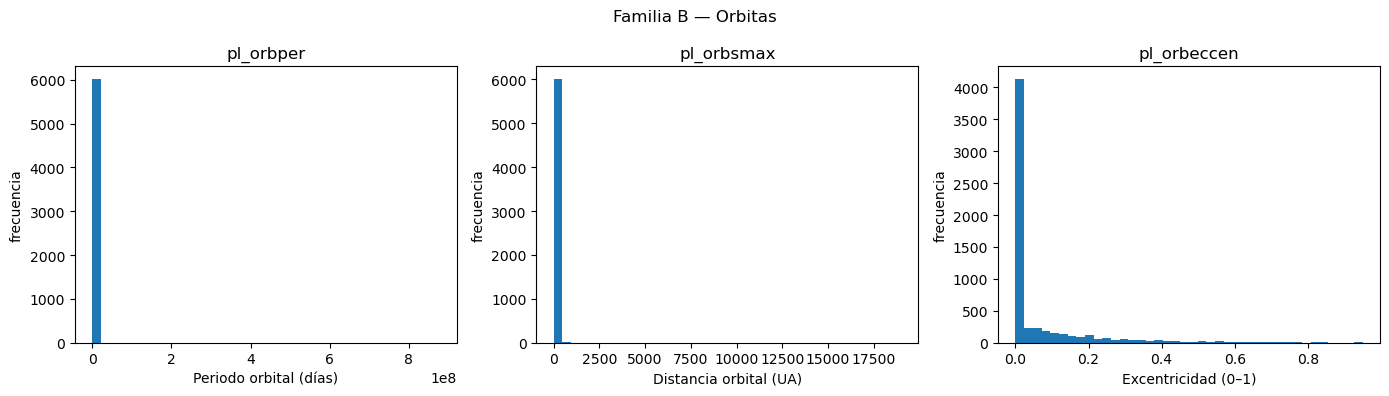

In [25]:
vars_b = ['pl_orbper','pl_orbsmax','pl_orbeccen']

units_b = {
    'pl_orbper': 'Periodo orbital (días)',
    'pl_orbsmax': 'Distancia orbital (UA)',
    'pl_orbeccen': 'Excentricidad (0–1)'
}

# Histogramas
plt.figure(figsize=(14,4))

i = 1
for col in vars_b:
    plt.subplot(1,3,i)
    plt.hist(df_work[col], bins=40)
    plt.title(col)
    plt.xlabel(units_b[col]) 
    plt.ylabel("frecuencia")
    i = i + 1

plt.suptitle("Familia B — Orbitas")
plt.tight_layout()
plt.show()


* `pl_orbper (periodo orbital)`: La distribución muestra una fuerte concentración de planetas con periodos orbitales muy cortos, lo que indica que la mayoría de exoplanetas detectados orbitan muy cerca de su estrella.

* `pl_orbsmax (distancia a la estrella)`: La distancia orbital presenta un comportamiento similar, con una gran acumulación de planetas a distancias pequeñas y algunos casos extremos a distancias muy grandes.

* `pl_orbeccen (excentricidad orbital)`: La mayor parte de los planetas presenta excentricidades bajas, concentradas cerca de cero, aunque existe una cola hacia valores altos, indicando la presencia de sistemas con órbitas significativamente elípticas.

**VISUALIZACIÓN FAMILIA D — PROPIEDADES DEL PLANETA**

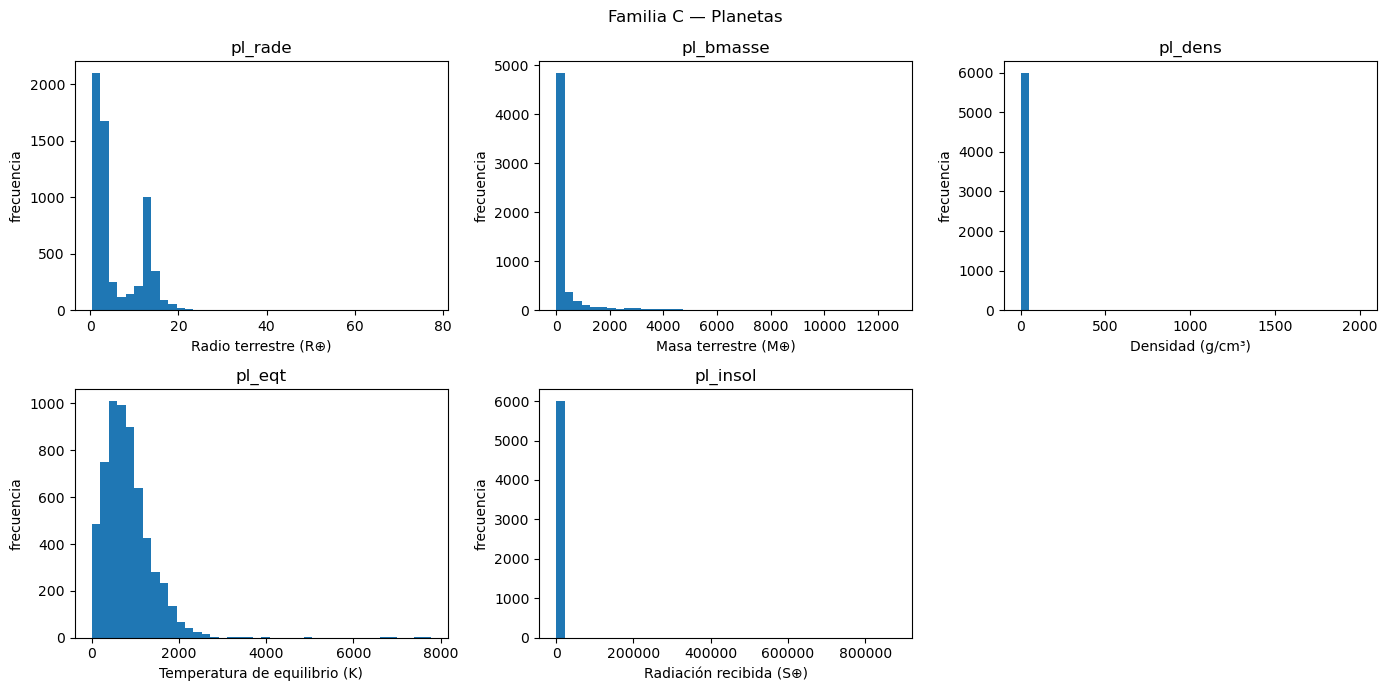

In [26]:
vars_c = ['pl_rade','pl_bmasse','pl_dens','pl_eqt','pl_insol']

units_c = {
    'pl_rade': 'Radio terrestre (R⊕)',
    'pl_bmasse': 'Masa terrestre (M⊕)',
    'pl_dens': 'Densidad (g/cm³)',
    'pl_eqt': 'Temperatura de equilibrio (K)',
    'pl_insol': 'Radiación recibida (S⊕)'
}

# Histogramas
plt.figure(figsize=(14,7))

i = 1
for col in vars_c:
    plt.subplot(2,3,i)
    plt.hist(df_work[col], bins=40)
    plt.title(col)
    plt.xlabel(units_c[col]) 
    plt.ylabel("frecuencia")
    i = i + 1

plt.suptitle("Familia C — Planetas")
plt.tight_layout()
plt.show()

* `pl_rade (radio del planeta)`: La distribución muestra una fuerte concentración de planetas con radios pequeños, lo que indica que la mayoría de exoplanetas detectados tienen tamaños comparables o moderadamente superiores al de la Tierra.

* `pl_bmasse (masa del planeta)`: La mayoría de masas se agrupan en valores bajos, lo que es coherente con un conjunto dominado por planetas pequeños/medios y con la dificultad de detectar planetas muy masivos en todos los rangos.

* `pl_dens (densidad del planeta)`: La densidad muestra una distribución muy concentrada en valores bajos, con la mayoría de planetas agrupados en un rango reducido.

* `pl_eqt (temperatura de equilibrio)`: La distribución muestra un pico en temperaturas bajas–moderadas y una cola hacia valores muy altos, lo que sugiere que la mayoría de planetas se encuentran en entornos térmicos extremos, lejos de condiciones templadas tipo Tierra.

* `pl_insol (radiación recibida)`: Se aprecia una concentración fuerte en valores bajos de insolación y una cola extremadamente larga hacia valores muy altos, indicando que muchos planetas reciben poca energía mientras que unos pocos están sometidos a irradiaciones extremas.



**VISUALIZACIÓN FAMILIA E — PROPIEDADES DE LA ESTRELLA**

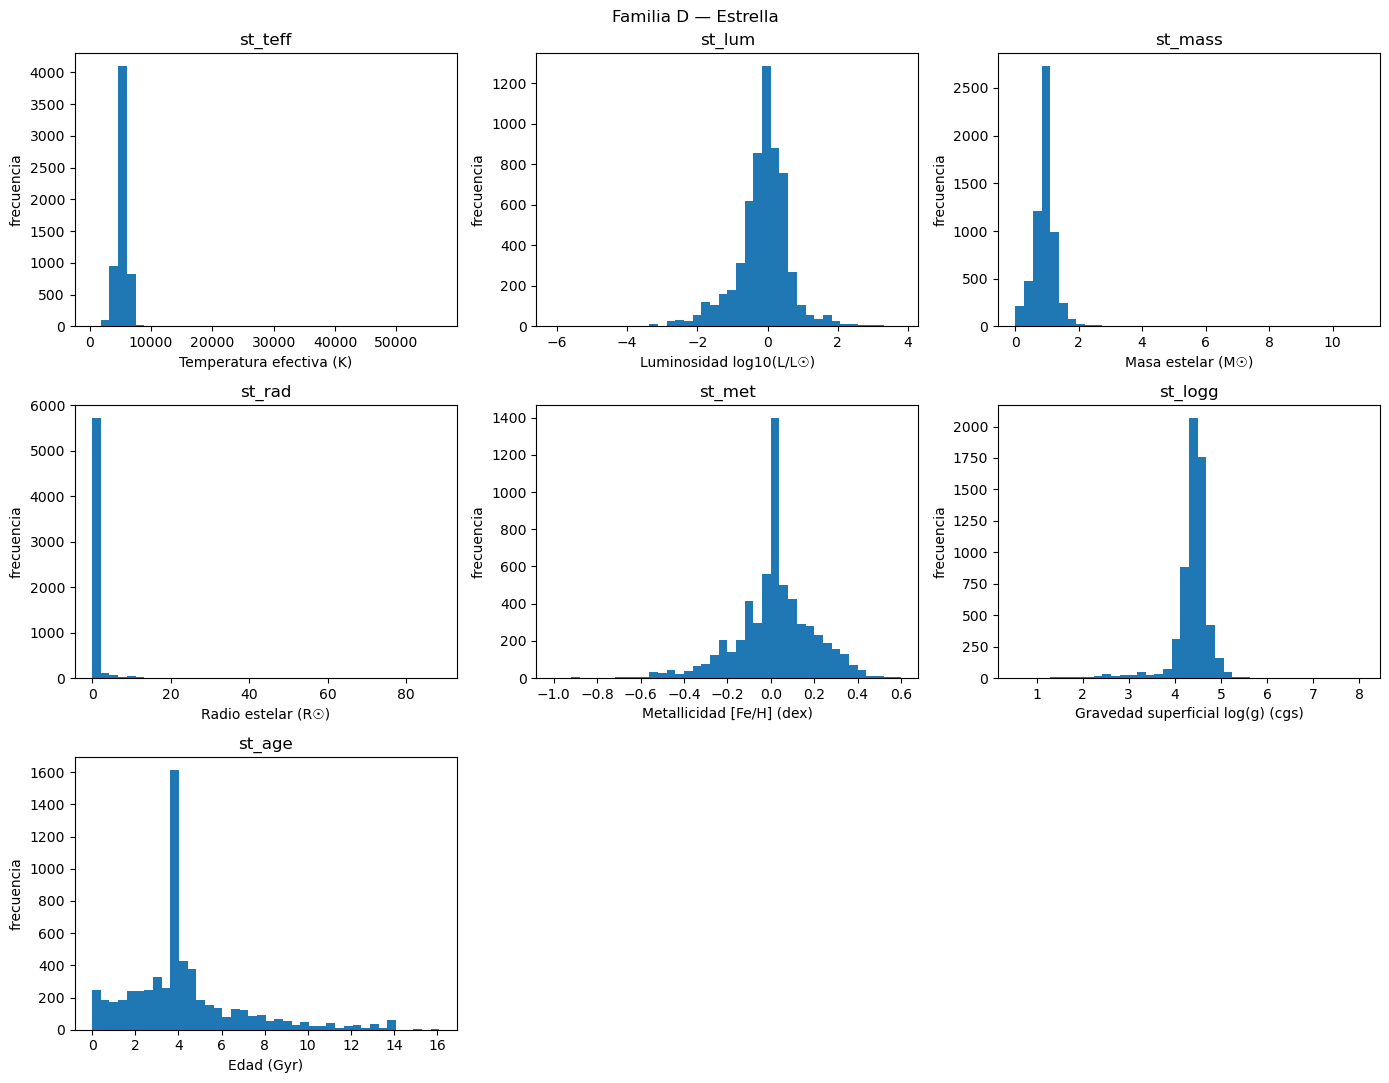

In [27]:
vars_d = ['st_teff','st_lum','st_mass','st_rad','st_met','st_logg','st_age']

units_d = {
    'st_teff': 'Temperatura efectiva (K)',
    'st_lum': 'Luminosidad log10(L/L☉)',
    'st_mass': 'Masa estelar (M☉)',
    'st_rad': 'Radio estelar (R☉)',
    'st_met': 'Metallicidad [Fe/H] (dex)',
    'st_logg': 'Gravedad superficial log(g) (cgs)',
    'st_age': 'Edad (Gyr)'
}


# Histogramas
plt.figure(figsize=(14,11))

i = 1
for col in vars_d:
    plt.subplot(3,3,i)
    plt.hist(df_work[col], bins=40)
    plt.title(col)
    plt.ylabel("frecuencia")
    plt.xlabel(units_d[col]) 
    i = i + 1

plt.suptitle("Familia D — Estrella")
plt.tight_layout()
plt.show()


* ``st_teff (temperatura efectiva)``: La distribución está fuertemente concentrada en temperaturas moderadas, indicando que la mayoría de estrellas anfitrionas son de tipo solar o más frías, con pocos casos extremos de estrellas muy calientes.

* ``st_lum (luminosidad)``: La distribución se agrupa cerca de valores centrales (en escala logarítmica), indicando que predominan estrellas con luminosidades moderadas, cercanas al orden de magnitud del Sol.

* ``st_mass (masa estelar)``: La masa se concentra alrededor de valores cercanos a 1 (en masas solares), lo que es coherente con una mayor presencia de estrellas parecidas al Sol en la muestra.

* ``st_rad (radio estelar)``: El radio muestra una fuerte concentración en valores bajos, indicando que muchas estrellas son de tamaño relativamente pequeño o moderado.

* ``st_met (metallicidad)``: La metallicidad se concentra alrededor de 0 (similar al Sol), lo que sugiere que muchas estrellas del conjunto tienen composiciones comparables a la solar.

* ``st_logg (gravedad superficial)``: La distribución se concentra en valores altos (típicos de estrellas compactas de secuencia principal), lo que apunta a un predominio de estrellas “estables” en el conjunto.

* ``st_age (edad)``: La edad muestra una distribución amplia, con concentración en edades intermedias, lo que indica una mezcla de sistemas relativamente jóvenes y maduros.

#### **Visualización de Outliers**

Dado que las variables físicas del dataset presentan rangos muy distintos y colas largas, la representación conjunta mediante boxplots en **escala lineal** provoca una fuerte compresión del núcleo de las distribuciones, dificultando la identificación visual de valores atípicos.

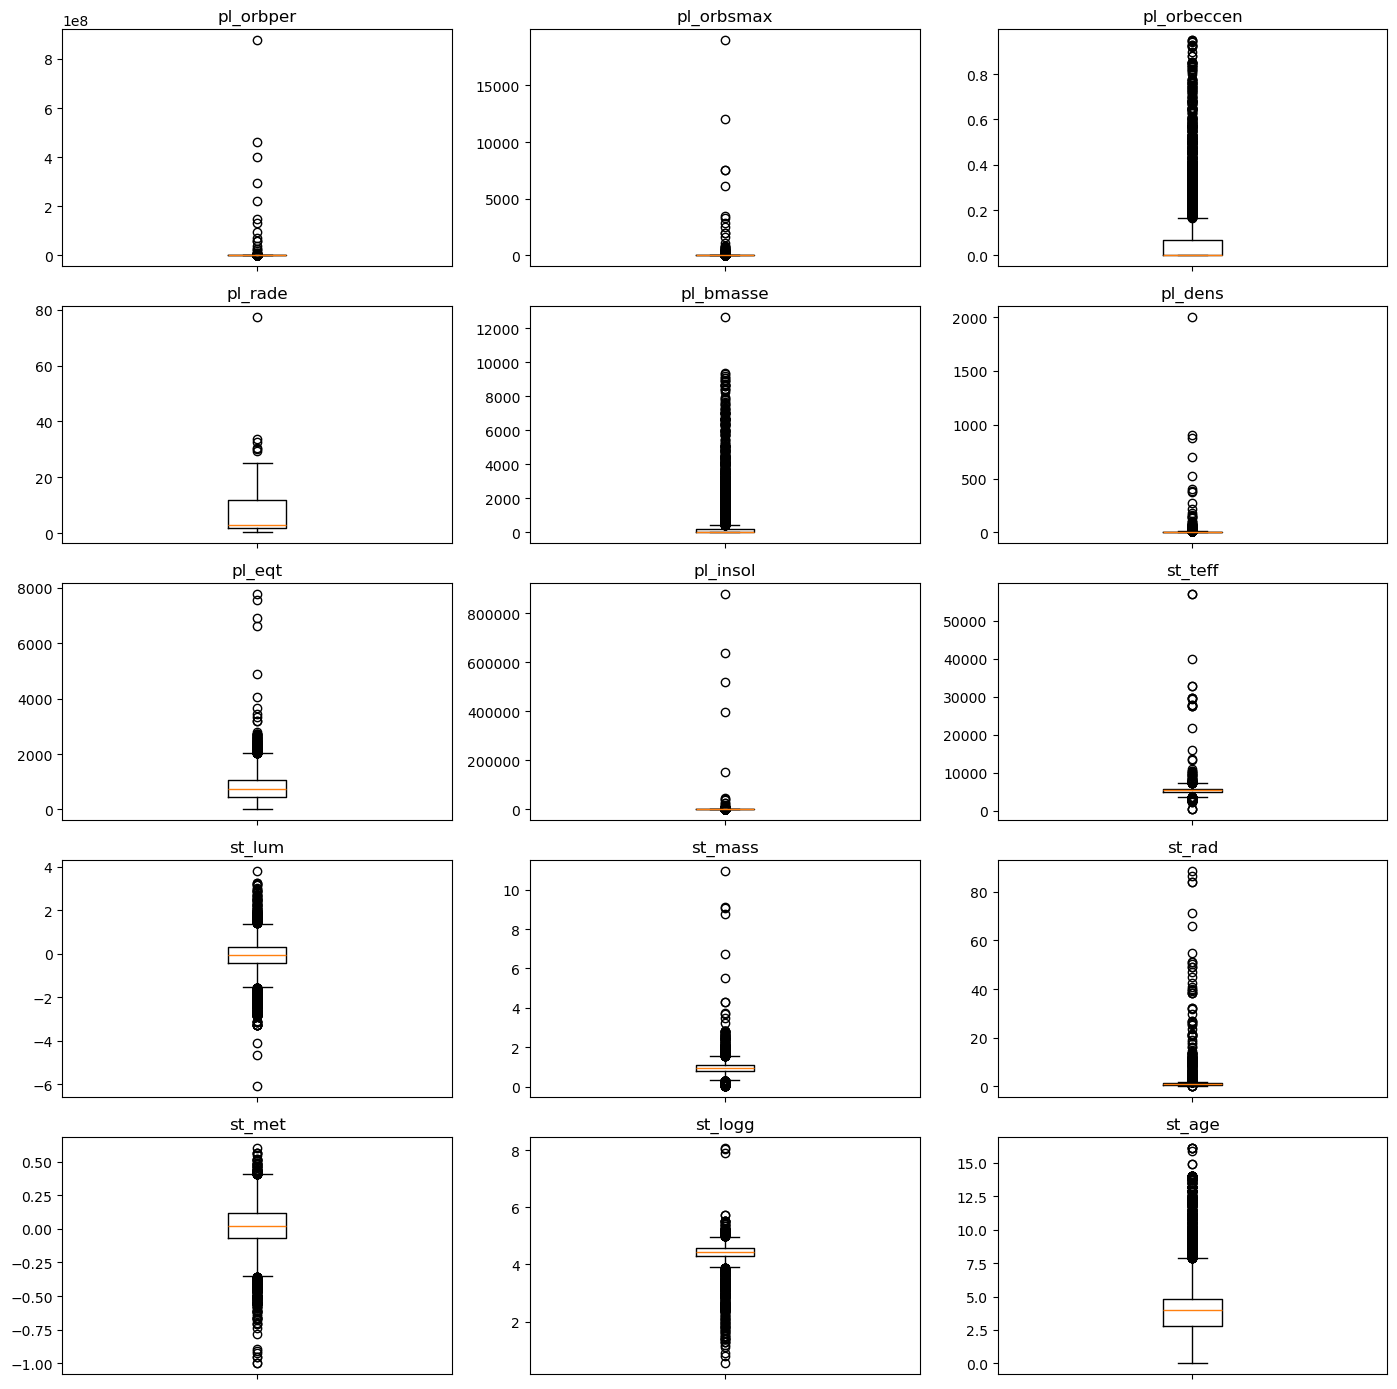

In [28]:
# Creamos una cuadrícula de subplots (5 filas x 3 columnas) para visualizar todas las variables numéricas
fig, axes = plt.subplots(5, 3, figsize=(14, 14))

# Convertimos la matriz de ejes en un array plano para poder recorrerlos fácilmente en un bucle
axes = axes.flatten()

# Índice para ir asignando cada variable a un subplot distinto
i = 0

# Recorremos todas las columnas numéricas del dataset
for col in num_cols:
    axes[i].boxplot(df_work[col]) # # Dibujamos el boxplot de cada variable
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', labelbottom=False)
    i += 1

plt.tight_layout()
plt.show()


Para mejorar la legibilidad del gráfico, se utiliza una escala logarítmica simétrica (symlog) en el eje vertical. Esta escala combina un comportamiento lineal alrededor del cero con un comportamiento logarítmico para valores de mayor magnitud, permitiendo visualizar simultáneamente la distribución central y los outliers sin que el boxplot quede aplastado.

Este ajuste se emplea exclusivamente con fines de visualización y no altera los datos originales ni el pipeline posterior del análisis.

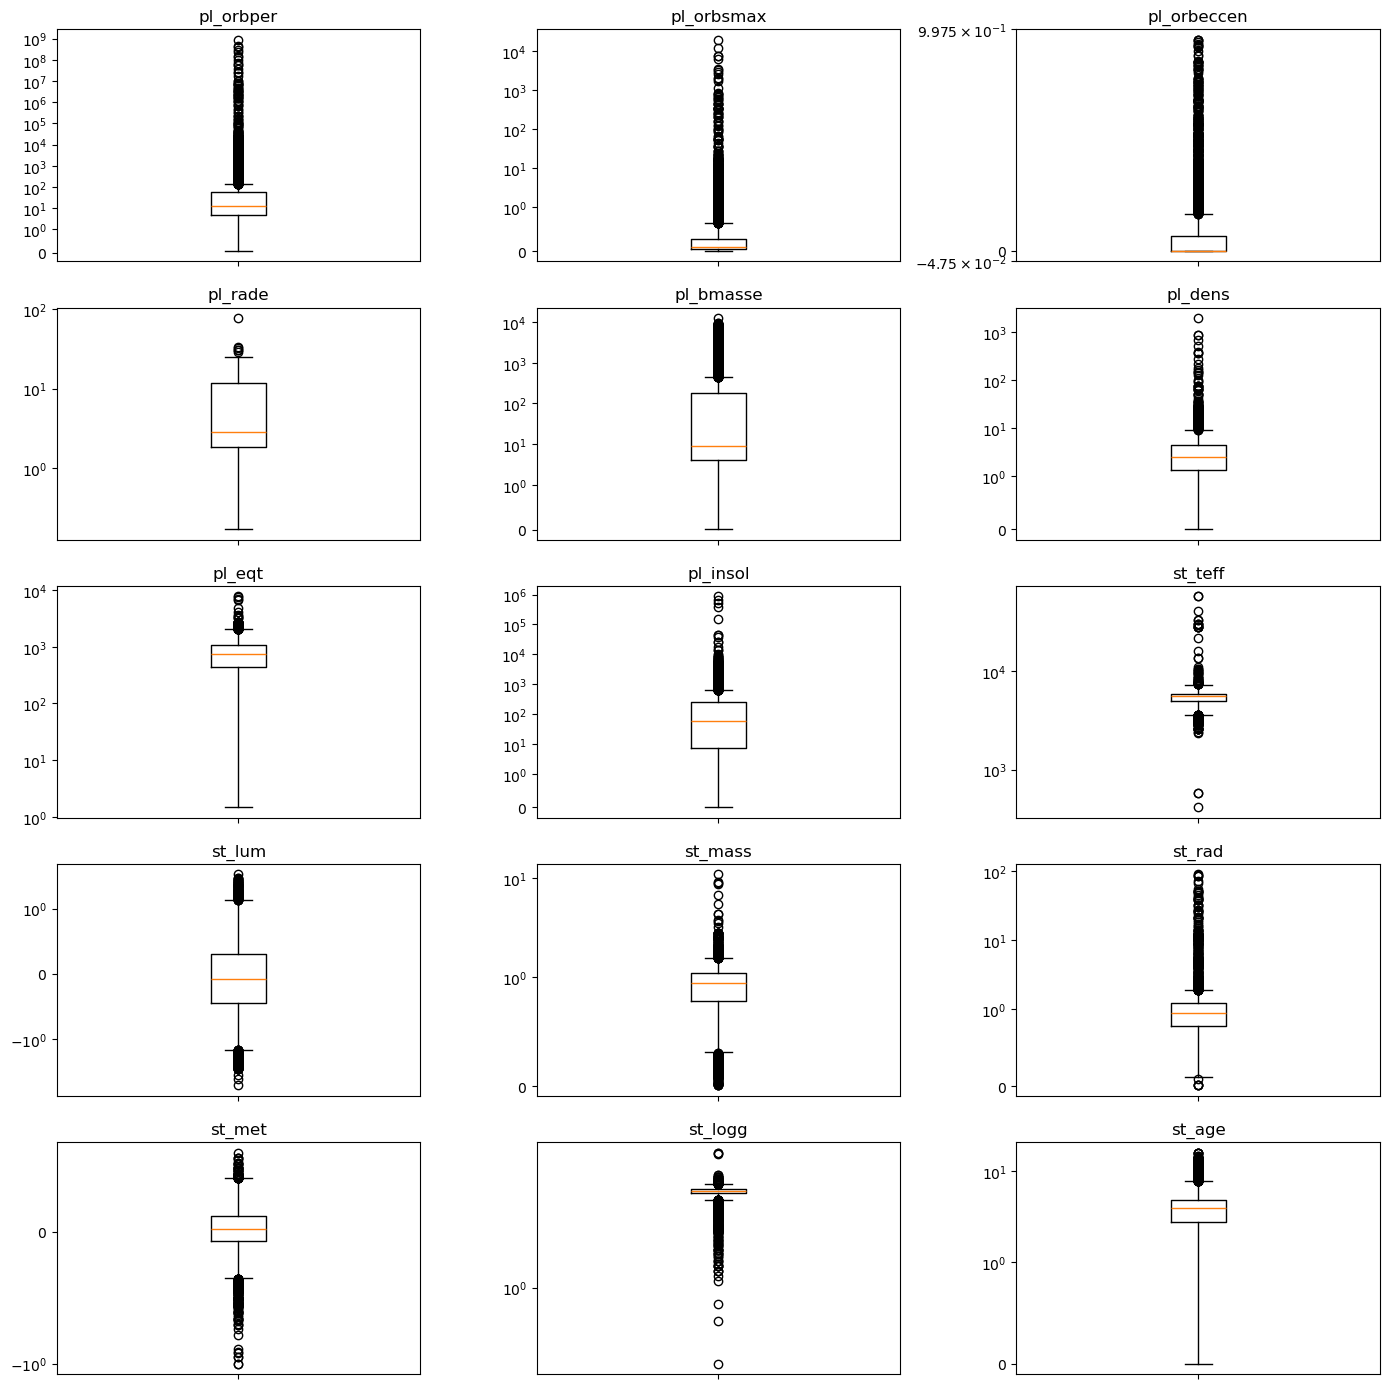

In [29]:
fig, axes = plt.subplots(5, 3, figsize=(14, 14))
axes = axes.flatten()

i = 0
for col in num_cols:
    axes[i].boxplot(df_work[col])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', labelbottom=False)
    axes[i].set_yscale('symlog', linthresh=1) # Escala logarítmica simétrica en el eje Y para visualizar mejor colas largas sin aplastar la caja central
    i += 1

plt.tight_layout()
plt.show()


La representación mediante boxplots en escala logarítmica simétrica permite visualizar simultáneamente el núcleo central de las distribuciones y la presencia de valores extremos en todas las variables físicas. Las variables orbitales muestran distribuciones altamente asimétricas y presencia de valores extremos, lo que justifica la necesidad de un escalado relativo posterior y de un enfoque basado en desviaciones relativas para la construcción del índice de habitabilidad.

Las variables asociadas a las propiedades físicas del planeta muestran distribuciones altamente asimétricas y una presencia clara de valores extremos, especialmente en masa, temperatura y radiación recibida. Este comportamiento refuerza la necesidad de aplicar un escalado relativo posterior y de utilizar un enfoque basado en desviaciones relativas para evitar que los valores extremos dominen el índice de habitabilidad.

Las variables estelares sugieren que muchas estrellas anfitrionas son cercanas a perfiles tipo solar (temperatura, masa y metallicidad alrededor de valores moderados), aunque existen casos extremos. Variables como st_rad y st_logg ayudan a detectar estrellas potencialmente evolucionadas, lo que es relevante para filtrar sistemas menos estables de cara a la habitabilidad a largo plazo.

## **5. Tratamiento de outliers**

Tras la revisión rápida de variables, tanto mediante histogramas como mediante boxplots, se observa un patrón común en gran parte de las magnitudes analizadas: distribuciones fuertemente asimétricas y concentradas cerca del origen, acompañadas de colas largas hacia valores elevados.

En los `histogramas`, muchas variables presentan la mayor parte de sus observaciones acumuladas en rangos muy bajos, mientras que el eje horizontal se extiende hasta valores muy altos debido a un número reducido de planetas con magnitudes extremas. Este efecto provoca que las distribuciones aparezcan “desplazadas” hacia la izquierda, evidenciando la presencia de observaciones muy alejadas del grueso de la muestra.

De forma complementaria, los `boxplots` confirman este comportamiento: las cajas intercuartílicas quedan comprimidas frente a rangos totales muy amplios, lo que dificulta la lectura visual y anticipa un impacto potencial sobre estadísticas sensibles a valores extremos, como la media, la desviación típica o determinadas relaciones de correlación.

Con el objetivo de cuantificar esta situación de forma sistemática, se aplica el criterio de Tukey (IQR) sobre una copia del dataset (`df_work`). Este procedimiento se utiliza exclusivamente con fines diagnósticos, permitiendo identificar qué variables concentran un mayor número de observaciones extremas y estimar la magnitud del fenómeno en el conjunto de datos.

In [30]:
# Creamos una copia del dataset para realizar el diagnóstico de outliers (se mantiene df_work intacto)
df_outlier_diag = df_work.copy()

# Definición de la función basada en el método de Tukey (IQR) para identificar valores atípicos en una variable numérica
def filtrar_outlier_tukey(x, threshold=1.5):

    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)

    # Rango intercuartílico (IQR)
    iqr = q3 - q1
    print(f'[q1={q1}, q3={q3}, iqr={iqr}]')

    # Definición de los límites inferior y superior según Tukey
    floor = q1 - threshold * iqr
    ceiling = q3 + threshold * iqr
    print(f'[floor={floor}, ceiling={ceiling}]')

    # Identificación de índices cuyos valores quedan fuera de estos límites
    outlier_indices = list(x.index[(x < floor) | (x > ceiling)])
    
    # Recuperamos los valores correspondientes a dichos índices
    outlier_values = list(x[outlier_indices])

    return outlier_indices, outlier_values


In [31]:
# Diccionario para almacenar el número de outliers detectados en cada variable
n_outliers = {}

# Aplicamos el método de Tukey a todas las columnas numéricas
for col in num_cols:
    outlier_indices, outlier_values = filtrar_outlier_tukey(df_outlier_diag[col])
    
    # Guardar el número total de outliers por variable
    n_outliers[col] = len(outlier_indices)

# Convertimos el resultado en una Serie y ordenamos de mayor a menor número de outliers
pd.Series(n_outliers).sort_values(ascending=False)

[q1=4.55139967, q3=56.35850143, iqr=51.807101759999995]
[floor=-73.15925297, ceiling=134.06915407]
[q1=0.052, q3=0.286, iqr=0.23399999999999999]
[floor=-0.299, ceiling=0.637]
[q1=0.0, q3=0.066, iqr=0.066]
[floor=-0.099, ceiling=0.165]
[q1=1.82, q3=11.9, iqr=10.08]
[floor=-13.3, ceiling=27.020000000000003]
[q1=4.16, q3=179.89178, iqr=175.73178000000001]
[floor=-259.43766999999997, ceiling=443.48945000000003]
[q1=1.32, q3=4.54, iqr=3.2199999999999998]
[floor=-3.51, ceiling=9.370000000000001]
[q1=443.66768868882133, q3=1075.0, iqr=631.3323113111787]
[floor=-503.33077827794676, ceiling=2021.998466966768]
[q1=7.13, q3=261.628, iqr=254.498]
[floor=-374.61699999999996, ceiling=643.375]
[q1=4952.0, q3=5885.38, iqr=933.3800000000001]
[floor=3551.93, ceiling=7285.450000000001]
[q1=-0.43985, q3=0.297, iqr=0.73685]
[floor=-1.545125, ceiling=1.402275]
[q1=0.778, q3=1.09, iqr=0.31200000000000006]
[floor=0.30999999999999994, ceiling=1.5580000000000003]
[q1=0.781, q3=1.23, iqr=0.44899999999999995]
[fl

pl_orbper      1176
pl_orbsmax     1082
pl_bmasse       988
pl_orbeccen     872
pl_insol        826
st_age          580
st_lum          462
st_mass         441
st_logg         436
st_rad          411
st_teff         356
pl_dens         309
st_met          274
pl_eqt          136
pl_rade           6
dtype: int64

Podemos observar el recuento de Outliers, detectado por Tukey en cada una de las variables. El recuento obtenido muestra que el número de registros clasificados como outliers es elevado. En este contexto, una **eliminación directa** de observaciones no resulta adecuada, ya que implicaría descartar una fracción sustancial del dataset y comprometer su representatividad global. También se ha considerado la **imputación directa mediante la mediana**. Sin embargo, este enfoque altera artificialmente las distribuciones originales y puede generar nuevos valores atípicos en reevaluaciones posteriores.


Para su tratamiento, se adopta una estrategia de `winsorización` basada en los límites definidos por Tukey. Este procedimiento consiste en identificar, para cada variable, un umbral inferior y superior (a partir del rango intercuartílico) y sustituir únicamente los valores que quedan fuera de dichos límites por el propio valor del umbral correspondiente. Es decir, los valores extremadamente bajos se elevan hasta el límite inferior, y los extremadamente altos se reducen hasta el límite superior.

De este modo, no se eliminan observaciones ni se reemplazan por valores centrales (como la mediana), sino que se mantiene cada registro dentro de su variable, limitando únicamente la influencia de magnitudes extremas. La información estructural del dataset se conserva, pero se evita que unos pocos valores muy alejados del rango típico distorsionen las escalas y las métricas posteriores.

La winsorización resulta especialmente adecuada en este trabajo por tres motivos principales:

1) **Robustez y estabilidad**: al recortar solo los extremos, se reduce la sensibilidad de estadísticas como la media, la desviación típica o ciertas correlaciones frente a valores muy altos o muy bajos, estabilizando el análisis sin alterar de forma significativa el comportamiento del grueso de la distribución.

2) **Conservación de información**: a diferencia del `drop`, se preserva el tamaño muestral y la representatividad del dataset. Además, a diferencia de la imputación por mediana, no se homogeneizan artificialmente observaciones muy distintas: un planeta “más caliente” que otro sigue siéndolo, aunque su valor quede acotado dentro de un rango razonable.

3) **Coherencia con el objetivo del índice de habitabilidad**: los planetas potencialmente similares a la Tierra se concentran en regiones próximas a valores moderados de masa, temperatura o insolación. Los casos extremos, aunque físicamente reales, son candidatos poco plausibles y, si no se controla su influencia, pueden dominar el cálculo del índice. La winsorización permite que el ranking final esté guiado por el patrón general del conjunto de datos y no por unos pocos valores extremos aislados.

Este enfoque representa un compromiso entre robustez estadística y preservación del significado físico de las variables. El efecto del procedimiento se valida visualmente mediante boxplots, observándose una reducción clara del impacto de colas largas sin pérdida de observaciones, preparando así el dataset para las fases posteriores de análisis y construcción del índice de habitabilidad.



In [32]:
# Definición de una función de winsorización basada en el criterio de Tukey (IQR). En lugar de eliminar los outliers, se recortan a los límites inferior y superior

def winsorizar_tukey(x, threshold=1.5):
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    
    # Rango intercuartílico
    iqr = q3 - q1

    # Definición de los límites según el método de Tukey
    floor = q1 - threshold * iqr
    ceiling = q3 + threshold * iqr

    # Aplicamos recorte (winsorización): los valores fuera del rango se sustituyen por el límite correspondiente
    return x.clip(lower=floor, upper=ceiling)


In [33]:
# Hacemos una copia del df_work para tener un df winsorizado con los outliers
df_wins = df_work.copy()

# Aplicamos la winsorización columna a columna sobre todas las variables numéricas
for col in num_cols:
    df_wins[col] = winsorizar_tukey(df_wins[col])


Una vez aplicada la winsorización sobre las variables numéricas, se vuelven a representar los boxplots con el objetivo de comprobar visualmente el efecto del tratamiento de outliers. Esta comparación permite verificar cómo los valores extremos han sido acotados, preservando la estructura central de las distribuciones y reduciendo la influencia de casos extremos antes de continuar con las etapas posteriores del análisis.

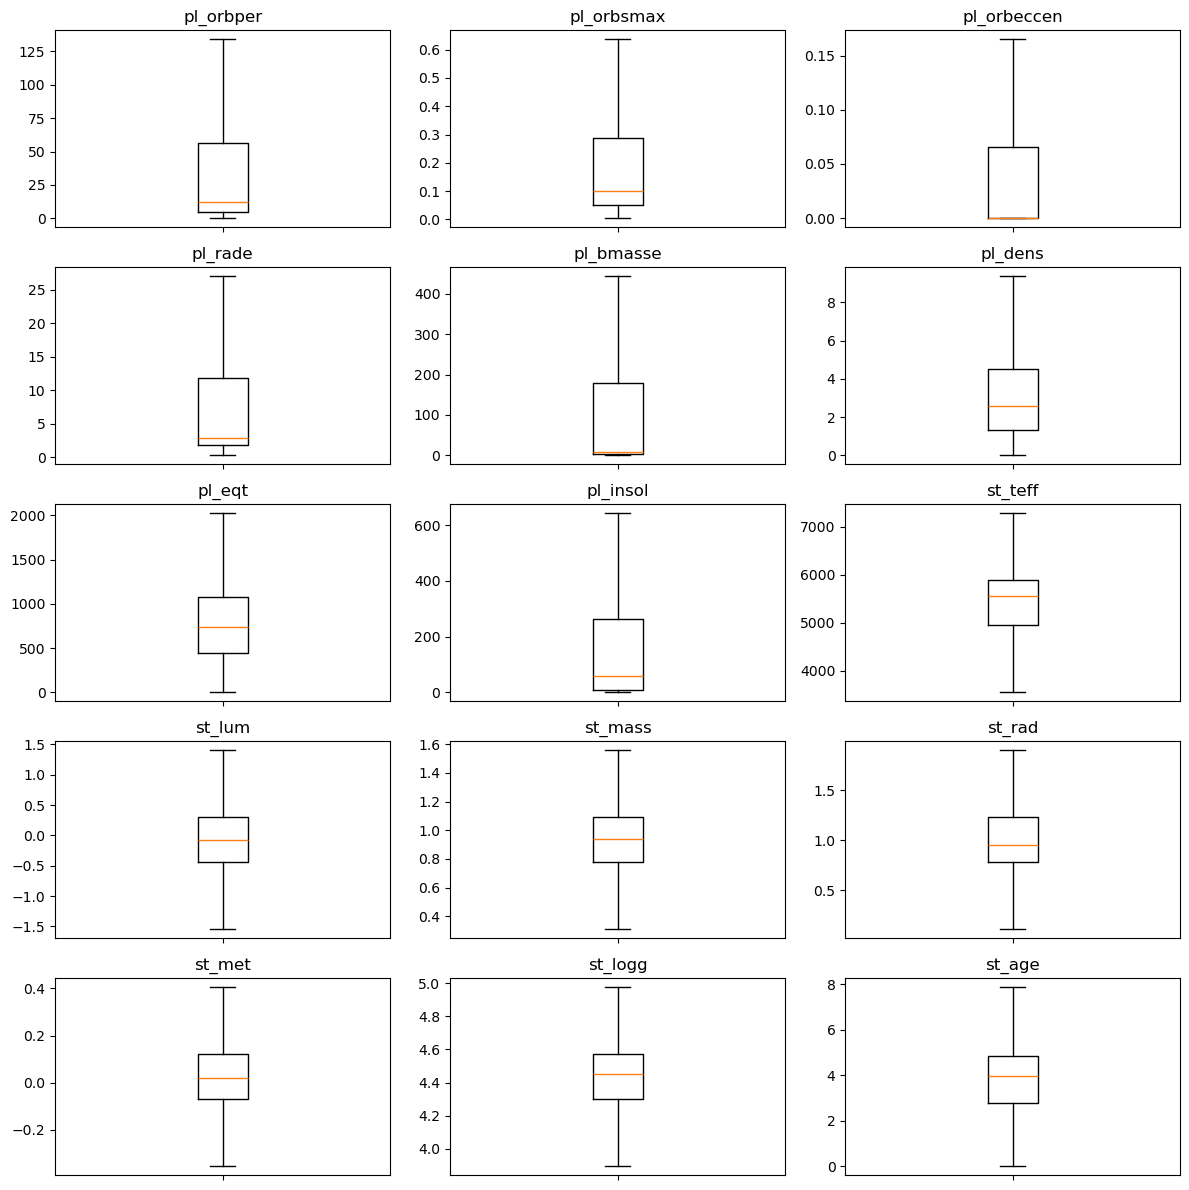

In [34]:
fig, axes = plt.subplots(5, 3, figsize=(12, 12))
axes = axes.flatten()

i = 0
for col in num_cols:
    axes[i].boxplot(df_wins[col])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', labelbottom=False)
    i += 1

plt.tight_layout()
plt.show()


## **6. Construcción y Caracterización estadística del dataset final**

Una vez estabilizadas las distribuciones mediante winsorización, se dispone de un conjunto de variables en el que el efecto de valores extremos ha sido controlado, sin pérdida de observaciones ni alteración del significado físico de los datos. Esto permite abordar el análisis descriptivo sobre una base más robusta, en la que las métricas resumen reflejan mejor el comportamiento global del conjunto de planetas.

En este apartado se calculan estadísticas básicas (medidas de centralidad y dispersión) para las variables seleccionadas, con el objetivo de caracterizar sus rangos típicos, identificar patrones generales y sentar las bases para el análisis de correlaciones y la posterior construcción del índice de habitabilidad.


In [35]:
# Hacemos una copia con el df final 

df_final = df_wins.copy() 

In [36]:
df_final.head(5)

,objectid,pl_name,hostname,pl_orbper,pl_orbsmax,pl_orbeccen,pl_rade,pl_bmasse,pl_dens,pl_eqt,pl_insol,st_teff,st_lum,st_mass,st_rad,st_met,st_logg,st_age
0,3.10209,K2-178 b,K2-178,8.747818,0.081711,0.000,3.55791,12.40000,1.510,840.290000,117.826000,5525.00,-0.283820,0.95109,0.887267,0.09,4.550,3.980
1,3.19225,HD 74698 c,HD 74698,134.069154,0.637000,0.165,14.00000,126.00000,0.252,151.773321,0.088000,5783.00,0.252850,1.03900,1.333000,0.07,4.120,7.847
2,3.12241,KMT-2016-BLG-1397L b,KMT-2016-BLG-1397L,134.069154,0.637000,0.000,12.70000,443.48945,5.900,115.771234,0.032603,5554.00,-0.071600,0.45000,0.953000,0.02,4.453,3.980
3,3.12499,GJ 1061 b,GJ 1061,3.204000,0.021000,0.165,1.10000,1.37000,5.660,388.105256,3.800000,3551.93,-1.545125,0.31000,0.156000,-0.08,4.975,7.000
4,3.2527,Kepler-102 b,Kepler-102,5.286965,0.055210,0.100,0.46000,1.10000,9.370,857.000000,90.000000,4909.00,-0.584360,0.80300,0.724000,0.11,4.600,1.100


### Comparación outliers antes y después de su tratamiento

Una vez completado el proceso de tratamiento de **NaN** y **Outliers** y antes de proceder al análisis formal del dataset final, se comparan a continuación los estadísticos descriptivos del conjunto tras la imputación (df_work) y del conjunto definitivo tras la winsorización (df_final). El objetivo de esta comparación es evaluar de forma explícita el impacto del tratamiento de valores extremos sobre las medidas de centralidad y dispersión, y verificar que dicho proceso actúa principalmente sobre las colas de las distribuciones.

In [37]:
# Antes del tratamiento de winsorizacion
desc_before = df_work[num_cols].describe().T

# Despues del tratamiento de winsorizacion
desc_after  = df_final[num_cols].describe().T

pd.concat({"df_work (antes winsorización)": desc_before, "df_final (después winsorización)": desc_after}, axis=1)

df_work (antes winsorización)                               \
                                    count           mean           std   
pl_orbper                          6021.0  506801.176508  1.493297e+07   
pl_orbsmax                         6021.0      14.905010  3.433862e+02   
pl_orbeccen                        6021.0       0.067133  1.431533e-01   
pl_rade                            6021.0       5.793161  5.337645e+00   
pl_bmasse                          6021.0     385.408151  1.106467e+03   
pl_dens                            6021.0       4.879719  3.450930e+01   
pl_eqt                             6021.0     812.477240  5.229454e+02   
pl_insol                           6021.0     782.286152  1.648455e+04   
st_teff                            6021.0    5417.099583  1.715163e+03   
st_lum                             6021.0      -0.132183  7.589986e-01   
st_mass                            6021.0       0.942274  4.208073e-01   
st_rad                             6021.0       1.482720  3.863681e+00   
st_met                             6021.0       0.015664  1.800273e-01   
st_logg                            6021.0       4.386424  4.299426e-01   
st_age                             6021.0       4.284589  2.659702e+00   

                                                                  \
                      min          25%          50%          75%   
pl_orbper    9.070629e-02     4.551400    12.309681    56.358501   
pl_orbsmax   3.856670e-03     0.052000     0.100000     0.286000   
pl_orbeccen  0.000000e+00     0.000000     0.000000     0.066000   
pl_rade      3.098000e-01     1.820000     2.830000    11.900000   
pl_bmasse    2.000000e-02     4.160000     9.100000   179.891780   
pl_dens      5.100000e-03     1.320000     2.560000     4.540000   
pl_eqt       1.481161e+00   443.667689   733.000000  1075.000000   
pl_insol     3.289901e-10     7.130000    57.630734   261.628000   
st_teff      4.150000e+02  4952.000000  5554.000000  5885.380000   
st_lum      -6.090000e+00    -0.439850    -0.071600     0.297000   
st_mass      9.400000e-03     0.778000     0.940000     1.090000   
st_rad       1.150000e-02     0.781000     0.953000     1.230000   
st_met      -1.000000e+00    -0.070000     0.020000     0.120000   
st_logg      5.410000e-01     4.300000     4.453000     4.570000   
st_age       0.000000e+00     2.800000     3.980000     4.830000   

                          df_final (después winsorización)               \
                      max                            count         mean   
pl_orbper    8.768941e+08                           6021.0    39.935950   
pl_orbsmax   1.900000e+04                           6021.0     0.210623   
pl_orbeccen  9.500000e-01                           6021.0     0.038713   
pl_rade      7.734210e+01                           6021.0     5.781285   
pl_bmasse    1.265150e+04                           6021.0   111.056395   
pl_dens      2.000000e+03                           6021.0     3.127858   
pl_eqt       7.777781e+03                           6021.0   801.980014   
pl_insol     8.782908e+05                           6021.0   176.102865   
st_teff      5.700000e+04                           6021.0  5356.568592   
st_lum       3.800000e+00                           6021.0    -0.118290   
st_mass      1.094000e+01                           6021.0     0.927113   
st_rad       8.847500e+01                           6021.0     1.026750   
st_met       6.000000e-01                           6021.0     0.019802   
st_logg      8.070000e+00                           6021.0     4.429461   
st_age       1.610000e+01                           6021.0     4.035104   

                                                                              \
                    std           min          25%          50%          75%   
pl_orbper     50.760766  9.070629e-02     4.551400    12.309681    56.358501   
pl_orbsmax     0.223685  3.856670e-03     0.052000     0.100000     0.286000   


La comparación de los estadísticos descriptivos antes y después del proceso de winsorización muestra que las medianas y cuartiles permanecen prácticamente invariantes en todas las variables. Por ejemplo:

* pl_orbper: misma mediana ≈ 12.3
* pl_orbsmax: misma mediana = 0.1
* pl_rade: misma mediana = 2.83
* pl_bmasse: misma mediana = 9.1
* pl_eqt: misma mediana = 733
* st_mass: misma mediana = 0.94
* st_logg: misma mediana = 4.453

Esto indica que la estructura central de las distribuciones se conserva. 

Sin embargo, los valores máximos y la desviación estándar se reducen de forma significativa, especialmente en variables con colas largas como el periodo orbital, la masa planetaria o la insolación. 

Por ejemplo: 

* En `pl_orbper` el valor máximo (max) pasa de 8.8×10⁸ a 134

Este comportamiento confirma que la winsorización actúa principalmente sobre los valores extremos, limitando su influencia sin alterar la población central del dataset. De este modo, se obtiene un conjunto de datos más estable y robusto para el cálculo posterior del índice de habitabilidad, evitando que unos pocos casos extremos dominen las métricas de similitud.

### Comparación media–mediana y análisis de asimetría
Con el objetivo de evaluar el grado de asimetría de las distribuciones tras el tratamiento de valores extremos mediante winsorización, se compara a continuación la media y la mediana de cada variable. Esta comparación permite identificar qué variables mantienen todavía colas largas o distribuciones sesgadas, ya que diferencias marcadas entre ambos estadísticos son indicativas de asimetría.

Este análisis complementa la inspección visual realizada previamente mediante boxplots y resulta especialmente relevante de cara a los pasos posteriores, ya que permite justificar la necesidad de aplicar un escalado relativo antes de construir el índice de habitabilidad, evitando que variables con distribuciones muy asimétricas dominen el cálculo de similitud.

In [38]:
round(df_final.describe().T[["mean","50%"]], 2)

,mean,50%
pl_orbper,39.94,12.31
pl_orbsmax,0.21,0.10
pl_orbeccen,0.04,0.00
pl_rade,5.78,2.83
pl_bmasse,111.06,9.10
pl_dens,3.13,2.56
pl_eqt,801.98,733.00
pl_insol,176.10,57.63
st_teff,5356.57,5554.00
st_lum,-0.12,-0.07


Al comparar la media con la mediana se observa que, incluso después del recorte de valores extremos mediante winsorización, varias variables planetarias siguen presentando diferencias importantes entre ambos estadísticos. En particular, el **periodo orbital**, la **masa** del planeta, la **insolación** y el **radio** planetario muestran medias claramente superiores a sus medianas, lo que indica la persistencia de colas derechas largas asociadas a un pequeño número de planetas con valores muy elevados.

Esto sugiere que, aunque la winsorización ha reducido la influencia de los casos más extremos, la asimetría del conjunto de exoplanetas se mantiene, reflejando la gran diversidad física de estos objetos.

En contraste, las **variables estelares** (masa, radio, metalicidad, gravedad superficial y edad) presentan medias muy próximas a sus medianas. Esta mayor homogeneidad observada en las variables estelares parece estar relacionada, por un lado, con la propia física de las estrellas, que impone relaciones fuertes entre sus propiedades y genera una población central dominante. Por otro lado, el hecho de que estos parámetros se estimen mediante modelos a partir de observaciones espectroscópicas también puede contribuir a compactar las distribuciones. Ambos factores actúan conjuntamente, dando lugar a variables estelares más estables y simétricas que las planetarias.

## **7. Análisis de Correlaciones**

Una vez caracterizado el dataset final y estabilizadas las distribuciones mediante winsorización, se analizan las relaciones entre las variables físicas seleccionadas mediante una matriz de correlación. Este análisis permite identificar patrones de co-variación coherentes con la física del sistema planeta–estrella, así como comprender cómo se organizan conjuntamente los distintos parámetros orbitales, planetarios y estelares.

El objetivo de este bloque no es eliminar variables, sino entender la estructura interna del espacio físico descrito por el dataset, verificando que las relaciones observadas son consistentes con las leyes que gobiernan estos sistemas y proporcionando contexto para la construcción posterior del índice de habitabilidad.

In [39]:
df_final[num_cols].corr()


,pl_orbper,pl_orbsmax,pl_orbeccen,pl_rade,pl_bmasse,pl_dens,pl_eqt,pl_insol,st_teff,st_lum,st_mass,st_rad,st_met,st_logg,st_age
pl_orbper,1.000000,0.992814,0.366592,0.447333,0.507963,-0.004128,-0.612182,-0.492896,0.025137,0.236470,0.048309,0.220907,-0.006439,-0.244038,-0.025003
pl_orbsmax,0.992814,1.000000,0.368408,0.455034,0.518043,-0.004315,-0.612117,-0.499696,0.060691,0.275197,0.083070,0.257459,0.001384,-0.280275,-0.029996
pl_orbeccen,0.366592,0.368408,1.000000,0.399258,0.428950,0.007249,-0.203283,-0.160815,-0.069981,0.117118,0.149788,0.194464,0.076254,-0.195919,0.082985
pl_rade,0.447333,0.455034,0.399258,1.000000,0.837581,-0.291891,0.055833,0.109561,0.188084,0.369917,0.318665,0.439589,0.190004,-0.423315,-0.035423
pl_bmasse,0.507963,0.518043,0.428950,0.837581,1.000000,0.039358,-0.023202,0.029828,0.122672,0.346021,0.298377,0.397750,0.153984,-0.377164,-0.067168
pl_dens,-0.004128,-0.004315,0.007249,-0.291891,0.039358,1.000000,0.004860,-0.009872,-0.122656,-0.081889,-0.073844,-0.102311,-0.104902,0.105347,-0.044037
pl_eqt,-0.612182,-0.612117,-0.203283,0.055833,-0.023202,0.004860,1.000000,0.874789,0.339368,0.294229,0.385216,0.304494,0.098435,-0.270234,-0.053794
pl_insol,-0.492896,-0.499696,-0.160815,0.109561,0.029828,-0.009872,0.874789,1.000000,0.361088,0.318163,0.367367,0.312891,0.138440,-0.279274,-0.014139
st_teff,0.025137,0.060691,-0.069981,0.188084,0.122672,-0.122656,0.339368,0.361088,1.000000,0.758049,0.692490,0.610936,0.141769,-0.568142,-0.121595
st_lum,0.236470,0.275197,0.117118,0.369917,0.346021,-0.081889,0.294229,0.318163,0.758049,1.000000,0.835768,0.890887,0.123723,-0.860900,-0.075210


### **Correlaciones más relevantes identificadas**

La matriz de correlación muestra relaciones fuertes y consistentes entre varias variables físicas del sistema planeta–estrella.

Las correlaciones más elevadas ya aparecen claramente en esta primera tabla:

* Periodo orbital (**pl_orbper**) – distancia orbital/semieje mayor (**pl_orbsmax**): r = 0.99
* Temperatura de equilibrio (**pl_eqt**) – insolación (**pl_insol**): r = 0.87
* Radio planetario (**pl_rade**) – masa planetaria (**pl_bmasse**): r = 0.84
* Radio estelar (**st_rad**) – masa estelar (**st_mass**): r ≈ 0.84
* Luminosidad (**st_lum**) – radio estelar (**st_rad**): r ≈ 0.89
* Gravedad superficial (**st_logg**) – radio estelar (**st_rad**): r = −0.95

Estas magnitudes no se relacionan de forma casual: describen directamente mecanismos físicos del sistema.

En concreto:

* La correlación 0.99 entre **periodo orbital** y **distancia** indica que ambas variables están midiendo esencialmente la misma escala orbital: cuanto más lejos está un planeta de su estrella, más tarda en completar una órbita.
* La correlación 0.87 entre **insolación** y **temperatura de equilibrio** muestra una relación energética directa: cuando aumenta la radiación recibida, aumenta la temperatura estimada del planeta.
* La correlación 0.84 entre **radio** y **masa planetaria** indica que los planetas grandes tienden a ser también más masivos, aunque no perfectamente, debido a diferencias de composición (densidad).

En el bloque estelar:

* **Masa**, **radio** y **luminosidad** presentan correlaciones entre 0.84 y 0.89, lo que significa que estrellas más masivas tienden a ser más grandes y más luminosas.
* La **gravedad superficial** muestra una correlación extremadamente negativa con el radio estelar (−0.95), lo que refleja que, a mayor tamaño de la estrella, menor es su gravedad en superficie.

Por el contrario:

* La edad estelar y la metalicidad presentan correlaciones débiles (|r| < 0.25) con la mayoría de variables, indicando que en este dataset no controlan directamente la estructura física inmediata del sistema.

#### **Visualización de la matriz de correlación**

Dado que la matriz de correlación en formato tabular puede resultar poco intuitiva cuando el número de variables es elevado, se representa a continuación mediante un mapa de calor (heatmap). Esta visualización permite identificar de forma inmediata patrones de correlación positiva y negativa, así como posibles bloques estructurales entre variables planetarias y estelares. De este modo, se obtiene una visión global del espacio físico antes de proceder a la construcción del índice de habitabilidad.

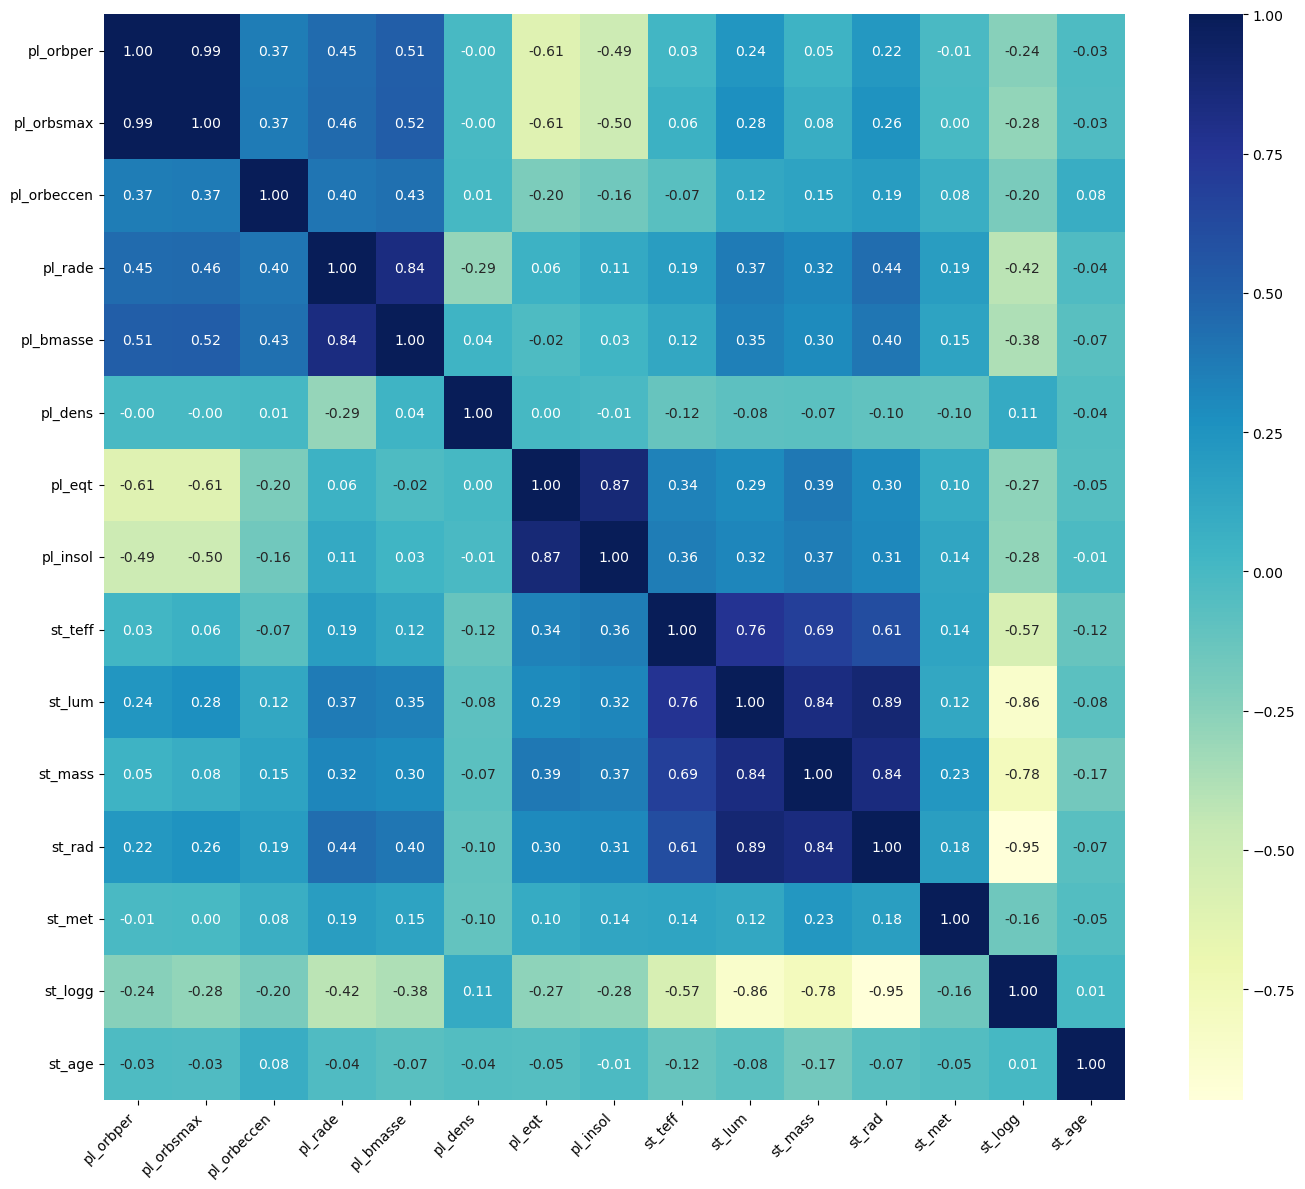

In [40]:
corr = df_final[num_cols].corr()

plt.figure(figsize=(14, 12))

sns.heatmap(
    corr,
    cmap="YlGnBu",
    annot=True,
    fmt=".2f" # Mostramos solo 2 decimales
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


### **Interpretación del Heatmap**

El mapa de calor permite pasar de una lectura numérica puntual a una visión estructural del espacio de variables, mostrando de forma inmediata qué grupos de parámetros se mueven conjuntamente y cuáles permanecen relativamente independientes.

A nivel visual se identifican claramente **cuatro bloques principales**:

#### ``Bloque estelar``

Las variables estelares:
* **Masa** (**st_mass**)
* **Radio** (**st_rad**)
* **Temperatura efectiva** (**st_teff**) 
* **luminosidad** (**st_lum**)

forman un bloque compacto de correlaciones positivas.

Esto indica que estas propiedades no varían de forma aislada:

* cuando aumenta la masa de la estrella, también aumenta su radio
* una estrella más grande tiende a ser más caliente
* y ambas cosas se traducen en mayor luminosidad.

Dentro de este mismo bloque:
 
* La **gravedad superficial** (**st_logg**) 

donde aparecen con correlaciones negativas intensas frente a **radio** y **luminosidad**, reflejando que estrellas más grandes y luminosas presentan menor gravedad superficial, lo cual es coherente con su definición física.


#### ``Bloque energético planeta–estrella``

La **temperatura de equilibrio del planeta** (**pl_eqt**) y la **insolación** (**pl_insol**) aparecen como un subbloque claramente definido.

Ambas variables se mueven en paralelo y además se conectan visualmente con las propiedades energéticas de la estrella (st_teff y st_lum), mostrando que:

* estrellas más calientes y luminosas envían más radiación
* los planetas reciben más energía
* y su temperatura de equilibrio aumenta en consecuencia.

Este bloque representa el canal energético completo desde la estrella hasta el planeta.

#### ``Bloque orbital``

El **periodo orbital** (**pl_orbper**) y la **distancia media a la estrella** (**pl_orbsmax**) forman un patrón muy marcado, mientras que su relación con **pl_eqt** y **pl_insol** aparece con signo opuesto.

Visualmente esto se traduce en que:

* planetas más lejanos (mayor pl_orbsmax) orbitan más lentamente (mayor pl_orbper)
* reciben menos energía, resultando en menores temperaturas de equilibrio.

La **excentricidad orbital** (**pl_orbeccen**) presenta colores más suaves frente al resto de variables, lo que indica que la forma de la órbita tiene un impacto secundario comparado con la distancia media.

#### ``Bloque planetario estructural``

El radio del planeta (**pl_rade**) y su masa (**pl_bmasse**) aparecen acoplados, mientras que la densidad (**pl_dens**) se mantiene visualmente mucho más independiente.

Esto sugiere que:

* tamaño y masa describen el volumen global del planeta
* mientras que la densidad aporta información complementaria sobre su composición interna y no simplemente sobre su escala.

#### ``Conclusiones Heatmap``

El heatmap muestra que el dataset está organizado alrededor de tres sistemas físicos acoplados:

* estructura estelar
* canal energético estrella–planeta
* geometría orbital

con un bloque planetario que captura tamaño, masa y composición. 

Esta visualización confirma que las variables seleccionadas representan procesos físicos distintos pero conectados, proporcionando una base coherente para la construcción posterior del índice de habitabilidad.

### **Identificación de pares con correlación elevada (|r| ≥ 0.70)**

Para disponer de una referencia rápida dentro del conjunto de relaciones observadas, se recogen a continuación los pares de variables con correlación elevada. Este resumen permite localizar de un vistazo qué parámetros están más estrechamente vinculados y actúa como apoyo al heatmap, sirviendo además como punto de referencia posterior cuando se analicen visualmente los resultados del índice de habitabilidad y se evalúe si los patrones obtenidos son coherentes con las dependencias físicas del sistema.

In [41]:
# Matriz de correlación (Pearson) entre las variables numéricas
corr = df_final[num_cols].corr()

umbral = 0.70  # a partir de este valor (en valor absoluto) consideramos correlación "alta"

# Nos quedamos solo con la mitad superior (sin la diagonal) para evitar duplicados
mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)

# Convertimos la matriz a formato "lista de pares" y filtramos por |r| >= umbral
pares_altos = (
    corr.where(mask)                 # deja NaN en la parte que no queremos
        .stack()                     # pasa a formato largo: (var_1, var_2) -> r
        .reset_index(name="r")       # lo convierte en DataFrame con columna 'r'
)

pares_altos["abs_r"] = pares_altos["r"].abs()                 # añadimos el valor absoluto
pares_altos = pares_altos[pares_altos["abs_r"] >= umbral]     # filtramos por el umbral
pares_altos = pares_altos.sort_values("abs_r", ascending=False).reset_index(drop=True)

pares_altos.rename(columns={"level_0": "var_1", "level_1": "var_2"}, inplace=True)

pares_altos


,var_1,var_2,r,abs_r
0,pl_orbper,pl_orbsmax,0.992814,0.992814
1,st_rad,st_logg,-0.949039,0.949039
2,st_lum,st_rad,0.890887,0.890887
3,pl_eqt,pl_insol,0.874789,0.874789
4,st_lum,st_logg,-0.860900,0.860900
5,st_mass,st_rad,0.844896,0.844896
6,pl_rade,pl_bmasse,0.837581,0.837581
7,st_lum,st_mass,0.835768,0.835768
8,st_mass,st_logg,-0.778570,0.778570
9,st_teff,st_lum,0.758049,0.758049


## **8. Definción formal del índice de habitabilidad**

El concepto de habitabilidad no es una magnitud directamente observable y depende del marco científico adoptado. Dado que el dataset no proporciona etiquetas explícitas de “planeta habitable” y que la mayoría de propiedades planetarias son estimaciones indirectas (proxies físicos), la habitabilidad no puede tratarse como una variable objetiva ni como un problema de clasificación supervisada.

En lugar de intentar definir condiciones absolutas de vida, se adopta un enfoque relativo: se asume que el único caso confirmado de planeta habitable es la Tierra, y que, bajo esta premisa, la forma más razonable de aproximar la habitabilidad es evaluar qué exoplanetas presentan condiciones físicas más similares a ella.

Este planteamiento evita introducir umbrales arbitrarios y permite formular el problema como una estimación continua basada en similitud física, limitada por la naturaleza incompleta e inferencial de los datos disponibles. El objetivo no es afirmar la existencia de vida, sino identificar planetas potencialmente compatibles con condiciones humanas conocidas.

$$
H_i \;=\; \frac{1}{\,1 + d\!\left(\mathbf{x}_i,\mathbf{x}_\oplus\right)\,}
$$

donde:

- $\mathbf{x}_i$ es el **vector de variables físicas del planeta $i$** (parámetros orbitales, planetarios y estelares seleccionados).

- $\mathbf{x}_\oplus$ es el **vector Tierra**, construido con los valores físicos de referencia del sistema Tierra–Sol en las mismas unidades que el dataset.

- $d(\mathbf{x}_i,\mathbf{x}_\oplus)$ es la **distancia (disimilitud) entre el planeta $i$ y la Tierra** en el espacio multidimensional definido por esas variables.

- $H_i$ es el **índice de habitabilidad relativo** del planeta $i$, acotado entre 0 y 1, donde valores más altos indican mayor similitud con las condiciones terrestres.




## **9. Construcción del vector Tierra**

Este vector representa las condiciones físicas del sistema Tierra–Sol para todas las magnitudes consideradas y actúa como referencia central dentro del espacio de variables del estudio. En otras palabras, establece el estado “base” a partir del cual se compararán los planetas del catálogo.

Dado que el dataset del NASA Exoplanet Archive contiene exclusivamente exoplanetas y no incluye a la Tierra, este vector se construye de forma externa utilizando valores físicos estándar procedentes de la literatura astronómica. Dichos valores se expresan explícitamente en las mismas unidades que las variables del dataset, garantizando la coherencia entre ambos.

Este vector constituye así la referencia común frente a la cual se evaluará cada registro del catálogo, permitiendo estimar posteriormente el grado de similitud física de cada exoplaneta respecto a las condiciones terrestres.

In [42]:
# Vector Tierra (valores de referencia Tierra-Sol, en las mismas unidades del dataset)
earth_values = {
    # Órbita (Tierra alrededor del Sol)
    "pl_orbper": 365.25,     # días
    "pl_orbsmax": 1.0,       # AU
    "pl_orbeccen": 0.0167,   # adimensional

    # Planeta (Tierra)
    "pl_rade": 1.0,          # radios Tierra
    "pl_bmasse": 1.0,        # masas Tierra
    "pl_dens": 5.51,         # g/cm^3 (densidad media Tierra)
    "pl_eqt": 255.0,         # K (temperatura de equilibrio aproximada)
    "pl_insol": 1.0,         # flujo relativo a la Tierra

    # Estrella (Sol)
    "st_teff": 5778.0,       # K
    "st_lum": 0.0,           # log10(L/Lsun) -> Sol = 0
    "st_mass": 1.0,          # masas solares
    "st_rad": 1.0,           # radios solares
    "st_met": 0.0,           # [Fe/H]
    "st_logg": 4.44,         # log(g) cgs
    "st_age": 4.6            # Gyr
}

# Construimos la Series en el MISMO orden de columnas que df_final
vector_tierra = pd.Series(earth_values)[num_cols]
vector_tierra.name = "Tierra"

vector_tierra


pl_orbper       365.2500
pl_orbsmax        1.0000
pl_orbeccen       0.0167
pl_rade           1.0000
pl_bmasse         1.0000
pl_dens           5.5100
pl_eqt          255.0000
pl_insol          1.0000
st_teff        5778.0000
st_lum            0.0000
st_mass           1.0000
st_rad            1.0000
st_met            0.0000
st_logg           4.4400
st_age            4.6000
Name: Tierra, dtype: float64

Una vez definido el vector Tierra, disponemos de una referencia común frente a la cual evaluar cada registro del catálogo, de modo que la “distancia” de un exoplaneta a este vector refleje su grado de similitud física respecto a las condiciones terrestres.

Aun así, antes de calcular desviaciones o distancias, es necesario tener en cuenta que las variables consideradas operan en escalas numéricas muy diferentes (por ejemplo, masas, radios y temperaturas). Por este motivo, el siguiente paso consiste en aplicar un escalado relativo que permita comparar todas las dimensiones de forma equilibrada antes de evaluar las diferencias respecto al vector Tierra.

## 10. Escalado relativo de variables

Una vez definido el vector Tierra como referencia física común, el siguiente paso consiste en expresar todas las variables en términos de **desviación relativa** respecto a este estado terrestre. El objetivo no es comparar magnitudes en sus unidades originales, sino cuantificar **cuánto se aleja cada planeta de la Tierra** en cada dimensión física dentro de una escala homogénea.

Dado que las variables presentan órdenes de magnitud y unidades muy distintas (radios, masas, temperaturas, luminosidad, etc.), la diferencia directa respecto al valor terrestre podría quedar dominada por aquellas magnitudes numéricamente mayores. Para evitarlo, cada dimensión se reescala utilizando como referencia su rango típico dentro del dataset, definido mediante percentiles robustos (P99–P01).

$$
x_i^{scaled}=\frac{x_i-x_{\oplus}}{P_{99}(x)-P_{01}(x)}
$$

donde:

- $x_i$ es el valor de la variable para el planeta $i$.
- $x_{\oplus}$ es el valor de referencia de esa misma variable en la Tierra (vector Tierra).
- $P_{99}(x)$ y $P_{01}(x)$ representan respectivamente el percentil 99 y el percentil 1 de dicha variable en el conjunto de datos.
- $x_i^{scaled}$ es la desviación física relativa del planeta $i$ respecto a la Tierra, expresada como fracción del rango típico de la variable.

Aplicando esta transformación a todas las dimensiones consideradas, cada exoplaneta queda representado por un **vector de desviaciones relativas**:

$$
\mathbf{x}_i^{scaled}=\left(
\frac{x_{i,1}-x_{\oplus,1}}{P_{99}(x_1)-P_{01}(x_1)},
\frac{x_{i,2}-x_{\oplus,2}}{P_{99}(x_2)-P_{01}(x_2)},
\dots,
\frac{x_{i,p}-x_{\oplus,p}}{P_{99}(x_p)-P_{01}(x_p)}
\right)
$$

Este vector recoge, dimensión por dimensión, cuánto se separa el planeta del estado terrestre en términos comparables. Así, el problema queda transformado en una representación multivariante adimensional, preparada para el cálculo posterior de desviaciones agregadas y la construcción del índice de habitabilidad.


In [43]:
# Calculamos los percentiles 1 y 99 para cada variable numérica
p01 = df_final[num_cols].quantile(0.01)
p99 = df_final[num_cols].quantile(0.99)

rango_tipico = p99 - p01

percentiles_df = pd.DataFrame({
    'P01': p01,
    'P99': p99,
    'Rango (P99-P01)': rango_tipico
})

print("Percentiles y rangos típicos por variable:")
percentiles_df

Percentiles y rangos típicos por variable:


,P01,P99,Rango (P99-P01)
pl_orbper,0.659436,134.069154,133.409718
pl_orbsmax,0.012806,0.637000,0.624194
pl_orbeccen,0.000000,0.165000,0.165000
pl_rade,0.750000,18.279612,17.529612
pl_bmasse,0.372200,443.489450,443.117250
pl_dens,0.164000,9.370000,9.206000
pl_eqt,65.707801,2021.998467,1956.290666
pl_insol,0.000538,643.375000,643.374462
st_teff,3551.930000,7204.580000,3652.650000
st_lum,-1.545125,1.402275,2.947400


### **Aplicación del escalado relativo**

Una vez calculados los percentiles P99 y P01 para cada variable, se aplica la fórmula de escalado relativo respecto al vector Tierra a cada exoplaneta del dataset. Esta transformación genera un nuevo dataset donde cada valor representa la **desviación relativa respecto a la Tierra**, expresada como fracción del rango típico de esa variable.

La transformación se aplica variable por variable sobre todo el conjunto de datos:

$$
x_i^{scaled}=\frac{x_i-x_{\oplus}}{P_{99}(x)-P_{01}(x)}
$$

De este modo, se obtiene una representación adimensional donde todas las magnitudes son directamente comparables, independientemente de sus unidades o escalas originales.

In [44]:
# Aplicamos el escalado relativo respecto al vector Tierra
# Fórmula: (x_i - x_earth) / (P99 - P01)

df_scaled = df_final.copy()

# Escalamos solo las variables numéricas
for col in num_cols:
 
    x_earth = vector_tierra[col]
    rango = rango_tipico[col]
    df_scaled[col] = (df_final[col] - x_earth) / rango

df_scaled.head()

,objectid,pl_name,hostname,pl_orbper,pl_orbsmax,pl_orbeccen,pl_rade,pl_bmasse,pl_dens,pl_eqt,pl_insol,st_teff,st_lum,st_mass,st_rad,st_met,st_logg,st_age
0,3.10209,K2-178 b,K2-178,-2.672235,-1.471160,-0.101212,0.145919,0.025727,-0.434499,0.299184,0.181583,-0.069265,-0.096295,-0.039191,-0.065933,0.118421,0.101852,-0.078961
1,3.19225,HD 74698 c,HD 74698,-1.732864,-0.581550,0.898788,0.741602,0.282092,-0.571149,-0.052767,-0.001418,0.001369,0.085787,0.031250,0.194759,0.092105,-0.296296,0.413525
2,3.12241,KMT-2016-BLG-1397L b,KMT-2016-BLG-1397L,-1.732864,-0.581550,-0.101212,0.667442,0.998583,0.042364,-0.071170,-0.001504,-0.061325,-0.024293,-0.440705,-0.027489,0.026316,0.012037,-0.078961
3,3.12499,GJ 1061 b,GJ 1061,-2.713790,-1.568423,0.898788,0.005705,0.000835,0.016294,0.068040,0.004352,-0.609440,-0.524233,-0.552885,-0.493624,-0.105263,0.495370,0.305655
4,3.2527,Kepler-102 b,Kepler-102,-2.698177,-1.513616,0.504848,-0.030805,0.000226,0.419292,0.307725,0.138333,-0.237909,-0.198263,-0.157853,-0.161422,0.144737,0.148148,-0.445746


### **Verificación del escalado relativo**

Una vez aplicada la transformación, es importante verificar que el escalado funciona correctamente. Para ello:

1. **Comprobamos las estadísticas descriptivas** del dataset escalado, observando que los valores numéricos ahora representan desviaciones relativas (pueden ser positivas o negativas).

2. **Evaluamos el significado físico**: un valor positivo indica que el planeta tiene un valor mayor que la Tierra en esa variable; un valor negativo indica que es menor. La magnitud del valor indica cuántas "veces el rango típico" se aleja de la Tierra.

3. **Verificamos algunos casos concretos**: observando cómo quedan representados diferentes exoplanetas tras el escalado.

In [45]:
df_scaled[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
pl_orbper,6021.0,-2.438458,0.380488,-2.737127,-2.703691,-2.645537,-2.315360,-1.732864
pl_orbsmax,6021.0,-1.264633,0.358358,-1.595887,-1.518759,-1.441859,-1.143875,-0.581550
pl_orbeccen,6021.0,0.133412,0.380176,-0.101212,-0.101212,-0.101212,0.298788,0.898788
pl_rade,6021.0,0.272755,0.299417,-0.039373,0.046778,0.104395,0.621805,1.484345
pl_bmasse,6021.0,0.248369,0.382865,-0.002212,0.007131,0.018280,0.403712,0.998583
pl_dens,6021.0,-0.258760,0.256160,-0.597969,-0.455138,-0.320443,-0.105366,0.419292
pl_eqt,6021.0,0.279601,0.242017,-0.129592,0.096442,0.244340,0.419161,0.903239
pl_insol,6021.0,0.272163,0.355348,-0.001554,0.009528,0.088021,0.405095,0.998447
st_teff,6021.0,-0.115377,0.217518,-0.609440,-0.226137,-0.061325,0.029398,0.412700
st_lum,6021.0,-0.040134,0.218733,-0.524233,-0.149233,-0.024293,0.100767,0.475767


In [46]:
# Ejemplo: comparación de algunos planetas antes y después del escalado
# Seleccionamos 3 planetas aleatorios para ilustrar la transformación

ejemplos_idx = df_final.sample(3, random_state=42).index

print("Comparación de valores originales vs. escalados (3 ejemplos):\n")

for idx in ejemplos_idx:
    planeta_nombre = df_final.loc[idx, 'pl_name']
    print(f"\n{'='*70}")
    print(f"Planeta: {planeta_nombre}")
    print(f"{'='*70}")
    
    # Mostramos algunas variables clave
    vars_ejemplo = ['pl_rade', 'pl_bmasse', 'pl_eqt', 'pl_orbsmax', 'st_teff', 'st_mass']
    
    for var in vars_ejemplo:
        val_original = df_final.loc[idx, var]
        val_scaled = df_scaled.loc[idx, var]
        val_tierra = vector_tierra[var]
        print(f"  {var:12s}: Original={val_original:8.2f}  |  Tierra={val_tierra:8.2f}  |  Escalado={val_scaled:7.3f}")
    
print(f"\n{'='*70}")

Comparación de valores originales vs. escalados (3 ejemplos):


Planeta: Kepler-620 b
  pl_rade     : Original=    3.32  |  Tierra=    1.00  |  Escalado=  0.132
  pl_bmasse   : Original=   11.00  |  Tierra=    1.00  |  Escalado=  0.023
  pl_eqt      : Original=  849.00  |  Tierra=  255.00  |  Escalado=  0.304
  pl_orbsmax  : Original=    0.11  |  Tierra=    1.00  |  Escalado= -1.433
  st_teff     : Original= 6155.00  |  Tierra= 5778.00  |  Escalado=  0.103
  st_mass     : Original=    1.15  |  Tierra=    1.00  |  Escalado=  0.120

Planeta: Kepler-603 b
  pl_rade     : Original=    2.65  |  Tierra=    1.00  |  Escalado=  0.094
  pl_bmasse   : Original=    7.51  |  Tierra=    1.00  |  Escalado=  0.015
  pl_eqt      : Original=  731.00  |  Tierra=  255.00  |  Escalado=  0.243
  pl_orbsmax  : Original=    0.16  |  Tierra=    1.00  |  Escalado= -1.345
  st_teff     : Original= 5808.00  |  Tierra= 5778.00  |  Escalado=  0.008
  st_mass     : Original=    1.01  |  Tierra=    1.00  |  Escalado

### **Interpretación del escalado relativo**

El resultado del escalado relativo proporciona una representación adimensional del dataset donde:

- **Valores cercanos a 0**: indican que el planeta tiene un valor similar a la Tierra en esa variable.
- **Valores positivos**: el planeta supera el valor terrestre en esa magnitud (más grande, más caliente, más masivo, etc.).
- **Valores negativos**: el planeta está por debajo del valor terrestre en esa magnitud.
- **Magnitud del valor**: cuanto mayor sea el valor absoluto, mayor es la separación respecto a la Tierra, expresada en términos del rango típico del dataset para esa variable.

Esta transformación homogeneiza todas las variables en una escala común, evitando que magnitudes con valores numéricos grandes (como temperaturas o periodos orbitales) dominen el cálculo de distancias frente a variables con valores pequeños (como la excentricidad o la metallicidad).

El dataset escalado (`df_scaled`) está ahora preparado para el cálculo de desviaciones absolutas y la posterior construcción del índice de habitabilidad mediante distancias euclídeas en este espacio multidimensional normalizado.

## **11. Cálculo de la desviación por variable** (valor absoluto del escalado relativo)

Una vez obtenido el vector de valores escalados $\mathbf{x}_i^{scaled}$ para cada planeta, el siguiente paso consiste en calcular, para cada variable, **cuánto se aleja realmente ese planeta de la Tierra**, sin importar si está por encima o por debajo del valor terrestre.

Para ello se toma el valor absoluto del escalado relativo. De esta forma, cada componente pasa a indicar simplemente **la distancia al estado Tierra en esa variable concreta**: cuanto mayor es el valor, más diferente es el planeta respecto a la Tierra en ese parámetro.

Formalmente, para cada planeta se define el vector de desviaciones como:

$$
\mathbf{d}_i=\left|\mathbf{x}_i^{scaled}\right|
$$

es decir, componente a componente:

$$
d_{i,j}=\left|x_{i,j}^{scaled}\right|
$$

donde:

- $x_{i,j}^{scaled}$ es el valor escalado relativo de la variable $j$ para el planeta $i$.
- $d_{i,j}$ es **cuánto difiere el planeta de la Tierra en esa variable concreta**.
- $\mathbf{d}_i$ es el **vector de diferencias físicas del planeta respecto a la Tierra**, expresado en una escala común.

Este paso convierte las diferencias físicas en magnitudes directamente comparables y prepara los datos para el cálculo posterior de una distancia global agregada, a partir de la cual se construirá el índice de habitabilidad.


In [ ]:
df_deviations = df_scaled.copy()
df_deviations[num_cols] = df_scaled[num_cols].abs()

df_deviations.head()

,objectid,pl_name,hostname,pl_orbper,pl_orbsmax,pl_orbeccen,pl_rade,pl_bmasse,pl_dens,pl_eqt,pl_insol,st_teff,st_lum,st_mass,st_rad,st_met,st_logg,st_age
0,3.10209,K2-178 b,K2-178,2.672235,1.471160,0.101212,0.145919,0.025727,0.434499,0.299184,0.181583,0.069265,0.096295,0.039191,0.065933,0.118421,0.101852,0.078961
1,3.19225,HD 74698 c,HD 74698,1.732864,0.581550,0.898788,0.741602,0.282092,0.571149,0.052767,0.001418,0.001369,0.085787,0.031250,0.194759,0.092105,0.296296,0.413525
2,3.12241,KMT-2016-BLG-1397L b,KMT-2016-BLG-1397L,1.732864,0.581550,0.101212,0.667442,0.998583,0.042364,0.071170,0.001504,0.061325,0.024293,0.440705,0.027489,0.026316,0.012037,0.078961
3,3.12499,GJ 1061 b,GJ 1061,2.713790,1.568423,0.898788,0.005705,0.000835,0.016294,0.068040,0.004352,0.609440,0.524233,0.552885,0.493624,0.105263,0.495370,0.305655
4,3.2527,Kepler-102 b,Kepler-102,2.698177,1.513616,0.504848,0.030805,0.000226,0.419292,0.307725,0.138333,0.237909,0.198263,0.157853,0.161422,0.144737,0.148148,0.445746


### **Estadísticas descriptivas de las desviaciones absolutas**

Una vez calculadas las desviaciones absolutas, es útil analizar su distribución mediante estadísticas descriptivas. Esto permite identificar:

- **Variables con mayor desviación media**: aquellas en las que, en promedio, los exoplanetas se alejan más de las condiciones terrestres.
- **Variabilidad de las desviaciones**: qué variables presentan mayor o menor dispersión en sus desviaciones.
- **Valores extremos**: planetas que se alejan mucho de la Tierra en ciertas dimensiones.

In [48]:
desc_deviations = df_deviations[num_cols].describe().T
desc_deviations_sorted = desc_deviations.sort_values('mean', ascending=False)

desc_deviations_sorted

,count,mean,std,min,25%,50%,75%,max
pl_orbper,6021.0,2.438458,0.380488,1.732864,2.315360,2.645537,2.703691,2.737127
pl_orbsmax,6021.0,1.264633,0.358358,0.581550,1.143875,1.441859,1.518759,1.595887
pl_dens,6021.0,0.321221,0.171423,0.000000,0.183467,0.347599,0.455138,0.597969
pl_eqt,6021.0,0.291101,0.228052,0.000000,0.101068,0.244340,0.419161,0.903239
pl_rade,6021.0,0.273570,0.298671,0.000000,0.046778,0.104395,0.621805,1.484345
pl_insol,6021.0,0.272486,0.355101,0.000003,0.009528,0.088021,0.405095,0.998447
pl_orbeccen,6021.0,0.267704,0.301095,0.000000,0.101212,0.101212,0.298788,0.898788
pl_bmasse,6021.0,0.248440,0.382819,0.000023,0.007131,0.018280,0.403712,0.998583
st_age,6021.0,0.214306,0.164112,0.000000,0.078961,0.164289,0.369333,0.585838
st_mass,6021.0,0.180330,0.154137,0.000000,0.056090,0.132334,0.264423,0.552885


### **Visualización de desviaciones absolutas por variable**

Para complementar el análisis estadístico, representamos mediante boxplots la distribución de las desviaciones absolutas en cada variable. Esta visualización permite identificar de forma intuitiva:

- La **tendencia central** de las desviaciones en cada dimensión física.
- La **variabilidad** de las desviaciones entre planetas.
- La presencia de **planetas con desviaciones extremas** respecto a la Tierra.

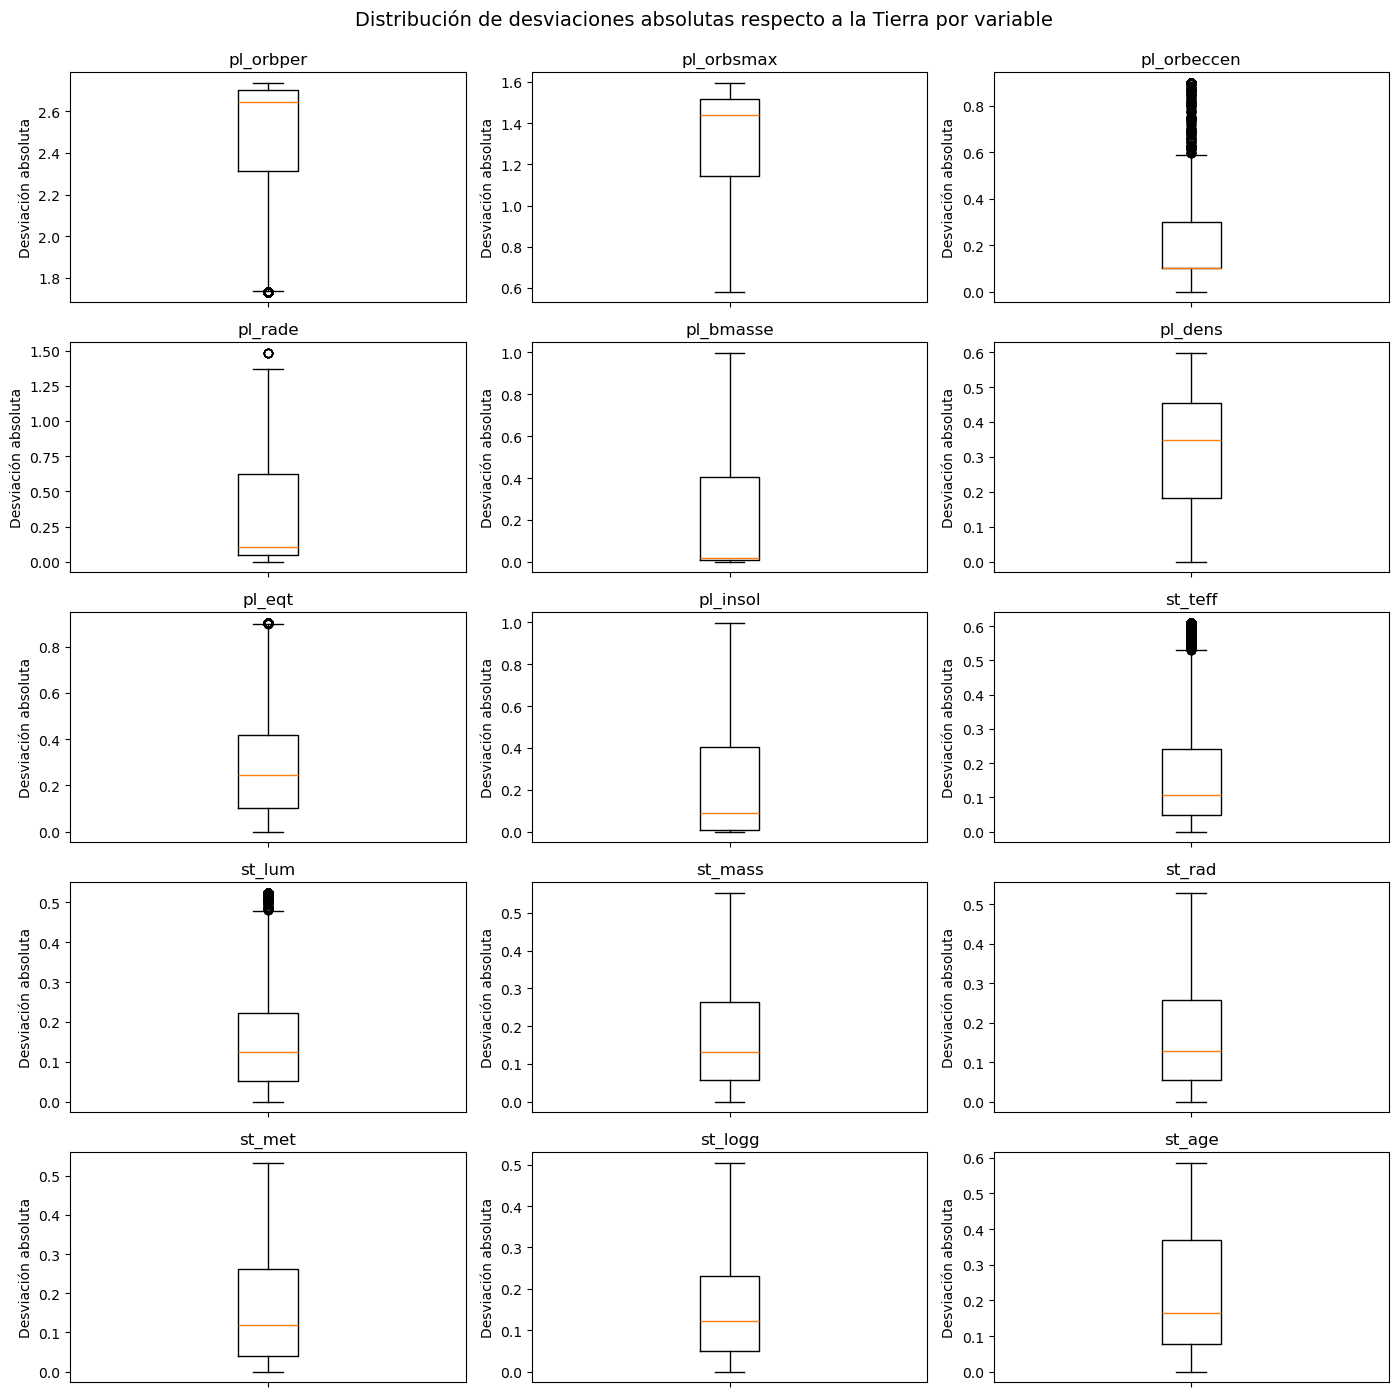

In [49]:
fig, axes = plt.subplots(5, 3, figsize=(14, 14))
axes = axes.flatten()

i = 0
for col in num_cols:
    axes[i].boxplot(df_deviations[col])
    axes[i].set_title(f'{col}')
    axes[i].set_ylabel('Desviación absoluta')
    axes[i].tick_params(axis='x', labelbottom=False)
    i += 1

plt.suptitle('Distribución de desviaciones absolutas respecto a la Tierra por variable', fontsize=14, y=0.995)
plt.tight_layout()
plt.show()

### **Interpretación de las desviaciones absolutas**

Los resultados obtenidos permiten identificar patrones relevantes en las desviaciones de los exoplanetas respecto a las condiciones terrestres:

**Variables con mayores desviaciones medias**: Las variables que muestran desviaciones medias más altas indican las dimensiones físicas en las que el conjunto de exoplanetas conocidos se aleja más significativamente de las condiciones terrestres. Por ejemplo las siguientes propiedades:
```pl_orbper, pl_orbsmax, pl_rade```

***Propidades de la órbita***
* `pl_orbper`: **periodo orbital del planeta** (en días). Cuántos días tarda el planeta en dar una vuelta completa a su estrella
* `pl_orbsmax`: **Distancia media a su estrella** (semieje mayor). A qué distancia está el planeta de su estrella.

***Propiedades del planeta***
* `pl_rade`: Radio del planeta (tamaño)
* `pl_bmasse`: Masa del planeta
* `pl_insol`: Radiación recibida
planetarias observadas.

**Variables con menores desviaciones**: Aquellas variables con desviaciones más reducidas sugieren que muchos exoplanetas comparten órdenes de magnitud similares a la Tierra en esas dimensiones, lo que puede estar relacionado tanto con sesgos observacionales (es más fácil detectar ciertos tipos de planetas) como con características físicas comunes de sistemas planetarios, como por ejemplo:

***Propidades de la estrella***
* `st_lum`: **Luminosidad de la estrella**. Cuánta luz emite la estrella en total (No es temperatura, es potencia)
* `st_mass`: **Masa de la estrella**. Qué grande es el Sol del planeta (Importa para estabilidad: Estrellas pequeñas viven millones de años.)
* `st_rad`: **Radio de la estrella**. Tamaño físico de la estrella (Sol grande: zona habitable más lejos)
* `st_met`: **Metallicidad**. Cuántos elementos “pesados” tiene la estrella (Baja metallicidad: difícil crear planetas tipo Tierra)
* `st_logg`: **Gravedad superficial de la estrella**. Qué tan “compacta” es la estrella (estrella normal - gigante roja)


**Preparación para la agregación**: El vector de desviaciones absolutas $\mathbf{d}_i$ obtenido para cada planeta constituye ahora una representación multidimensional de su alejamiento respecto a la Tierra, donde:

- Todas las variables están en una escala comparable (desviaciones relativas adimensionales).
- Todas las diferencias son positivas (valores absolutos).
- Cada dimensión conserva su significado físico original.

Este conjunto de vectores está preparado para el siguiente paso: el cálculo de una distancia euclídea global que agregue todas estas desviaciones individuales en una única métrica de disimilitud física, base del índice de habitabilidad.

## 12. **Agregación de desviaciones (distancia euclídea)**

Una vez calculadas las desviaciones absolutas por variable, el siguiente paso consiste en combinarlas en una única medida global que cuantifica el alejamiento total de cada planeta respecto al vector Tierra.

Esta agregación se realiza mediante la **distancia euclídea** en el espacio multidimensional definido por las variables físicas seleccionadas. Así, todas las discrepancias parciales se integran en un único valor escalar que resume, de forma directa, cuánto se aparta un exoplaneta de las condiciones terrestres.

Formalmente, para cada planeta \(i\), la distancia al vector Tierra se define como:

$$
D_i = \sqrt{\sum_{j=1}^{p} \left| x_{ij}^{\text{scaled}} \right|^2}
$$

donde:

- $x_{ij}^{\text{scaled}}$ es la desviación relativa escalada (en valor absoluto) de la variable $j$ para el planeta $i$.

- $p$ es el número total de variables consideradas.

- $D_i$ representa la **distancia euclídea al vector Tierra**, interpretada como una medida global de disimilitud física.

Este valor sintetiza todas las desviaciones individuales en una única distancia por planeta, permitiendo ordenar directamente los exoplanetas según su proximidad al estado terrestre y sirviendo como base para la construcción posterior del índice de habitabilidad.


In [50]:
# Calculamos la distancia euclídea al vector Tierra para cada planeta
# Fórmula: D_i = sqrt(sum(x_ij^2)) donde x_ij son las desviaciones escaladas

df_distance = df_deviations.copy()
df_distance['distancia_tierra'] = np.sqrt((df_deviations[num_cols] ** 2).sum(axis=1))

df_distance[['pl_name', 'hostname', 'distancia_tierra']].head(10)

,pl_name,hostname,distancia_tierra
0,K2-178 b,K2-178,3.114355
1,HD 74698 c,HD 74698,2.328289
2,KMT-2016-BLG-1397L b,KMT-2016-BLG-1397L,2.237671
3,GJ 1061 b,GJ 1061,3.490395
4,Kepler-102 b,Kepler-102,3.241160
5,Kepler-1446 b,Kepler-1446,3.415971
6,HD 13908 b,HD 13908,3.223060
7,HIP 9618 b,HIP 9618,2.984074
8,HD 202696 c,HD 202696,2.372298
9,Kepler-1697 b,Kepler-1697,2.842466


### **Estadísticas descriptivas de la distancia euclídea**

Una vez calculada la distancia euclídea para cada exoplaneta, analizamos su distribución mediante estadísticas descriptivas.

In [51]:
print(df_distance['distancia_tierra'].describe())

count    6021.000000
mean        3.003984
std         0.434522
min         1.844252
25%         2.724459
50%         3.116834
75%         3.302543
max         3.943040
Name: distancia_tierra, dtype: float64


### **Visualización de la distribución de distancias**

Para comprender mejor cómo se distribuyen las distancias euclídeas al vector Tierra en el conjunto de exoplanetas, representamos su distribución mediante un histograma y un boxplot. Estas visualizaciones permiten:

- Identificar la **forma de la distribución** (simétrica, asimétrica, multimodal).
- Detectar la presencia de **grupos diferenciados** de planetas según su similitud con la Tierra.
- Localizar **valores atípicos** que representen planetas extremadamente similares o diferentes.

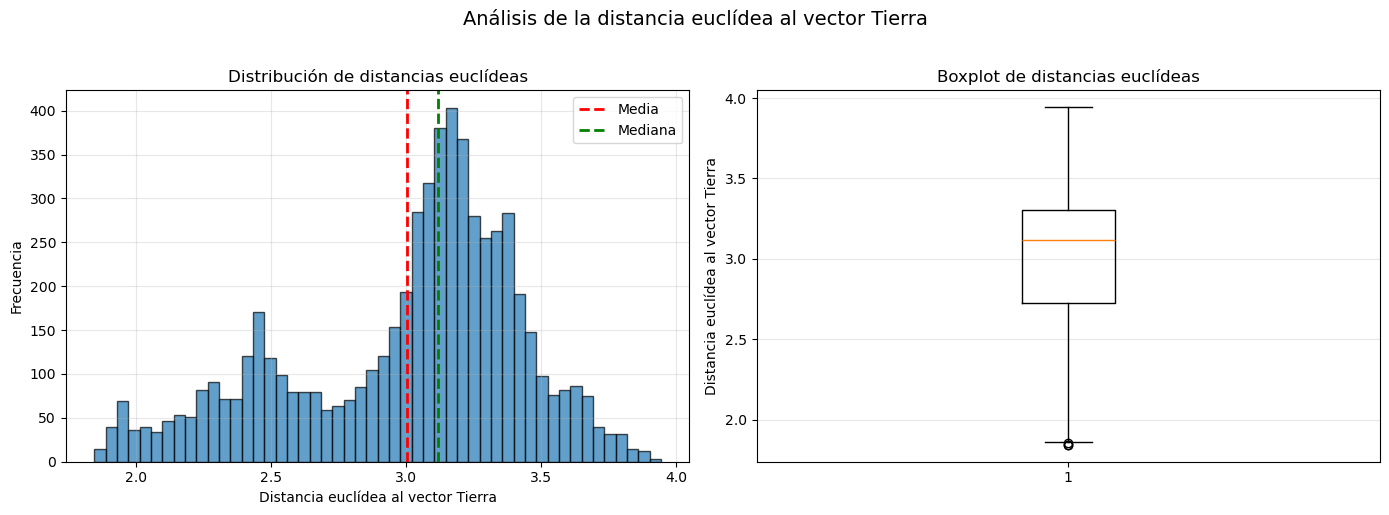

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_distance['distancia_tierra'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Distancia euclídea al vector Tierra')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de distancias euclídeas')
axes[0].axvline(df_distance['distancia_tierra'].mean(), color='red', linestyle='--', linewidth=2, label='Media')
axes[0].axvline(df_distance['distancia_tierra'].median(), color='green', linestyle='--', linewidth=2, label='Mediana')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].boxplot(df_distance['distancia_tierra'], vert=True)
axes[1].set_ylabel('Distancia euclídea al vector Tierra')
axes[1].set_title('Boxplot de distancias euclídeas')
axes[1].grid(alpha=0.3, axis='y')

plt.suptitle('Análisis de la distancia euclídea al vector Tierra', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### **Análisis detallado de planetas extremos**

Para entender qué hace que un planeta sea similar o diferente a la Tierra, comparamos las características físicas de:

- El planeta **más similar** (menor distancia euclídea)
- El planeta **más diferente** (mayor distancia euclídea)
- La **Tierra** (referencia)

Esta comparación permite identificar en qué variables concretas se producen las mayores diferencias.

In [53]:
idx_mas_similar = df_distance['distancia_tierra'].idxmin()
idx_mas_diferente = df_distance['distancia_tierra'].idxmax()

planeta_similar = df_final.loc[idx_mas_similar, 'pl_name']
planeta_diferente = df_final.loc[idx_mas_diferente, 'pl_name']

print(f"\nPlaneta más similar: {planeta_similar} (distancia = {df_distance.loc[idx_mas_similar, 'distancia_tierra']:.4f})")
print(f"Planeta más diferente: {planeta_diferente} (distancia = {df_distance.loc[idx_mas_diferente, 'distancia_tierra']:.4f})")
print("\n" + "-"*90)
print(f"{'Variable':15s} {'Más similar':>15s} {'Tierra':>15s} {'Más diferente':>15s}")
print("-"*90)

for var in num_cols:
    val_similar = df_final.loc[idx_mas_similar, var]
    val_tierra = vector_tierra[var]
    val_diferente = df_final.loc[idx_mas_diferente, var]
    print(f"{var:15s} {val_similar:15.2f} {val_tierra:15.2f} {val_diferente:15.2f}")

print("-"*90)


Planeta más similar: KMT-2021-BLG-0912L b (distancia = 1.8443)
Planeta más diferente: KELT-9 b (distancia = 3.9430)

------------------------------------------------------------------------------------------
Variable            Más similar          Tierra   Más diferente
------------------------------------------------------------------------------------------
pl_orbper                134.07          365.25            1.48
pl_orbsmax                 0.64            1.00            0.03
pl_orbeccen                0.00            0.02            0.00
pl_rade                    1.49            1.00           21.20
pl_bmasse                  2.81            1.00          443.49
pl_dens                    4.67            5.51            0.53
pl_eqt                   147.54          255.00         2022.00
pl_insol                   0.09            1.00          643.38
st_teff                 5554.00         5778.00         7285.45
st_lum                    -0.07            0.00            1

### **Interpretación de la agregación mediante distancia euclídea**

La distancia euclídea calculada para cada exoplaneta representa una **medida sintética de disimilitud física global** respecto a las condiciones terrestres. Sus principales características son:

**Propiedades de la métrica**:
- **Valores bajos** (cercanos a 0): indican que el planeta presenta características físicas muy similares a la Tierra en el conjunto de variables consideradas.
- **Valores altos**: indican que el planeta se aleja significativamente de las condiciones terrestres en múltiples dimensiones físicas.
- **Escala comparable**: al estar calculada sobre variables previamente escaladas mediante percentiles, todas las dimensiones contribuyen de forma equilibrada, sin que magnitudes numéricamente grandes dominen el resultado.

**Información agregada**:
- La distancia euclídea integra las desviaciones parciales de todas las variables (orbitales, planetarias y estelares) en un único valor escalar.
- Un planeta puede tener desviaciones moderadas en muchas variables o desviaciones extremas en pocas; ambos casos se reflejarán en la distancia global.
- La métrica es **simétrica** (no depende del orden de comparación) y cumple la **desigualdad triangular**, propiedades fundamentales de una distancia matemática.

## 13. **Cálculo del índice de habitabilidad** 

Una vez obtenida la distancia euclídea global $D_i$ de cada planeta respecto al **vector Tierra** en el espacio de variables físicas escaladas, se define el **índice de habitabilidad relativo** como una transformación directa de dicha distancia.

El objetivo es convertir la medida de disimilitud física en un índice acotado entre 0 y 1, donde valores más altos indican mayor similitud con la Tierra.

$$
H_i = \frac{1}{1 + D_i}
$$

donde:

- $H_i$ es el **índice de habitabilidad relativo** del planeta $i$.
- $D_i$ es la **distancia euclídea al vector Tierra**, calculada a partir del vector de desviaciones absolutas escaladas.
- El índice queda acotado en el intervalo $(0,1)$, siendo:
  - $H_i = 1$: planeta idéntico a la Tierra en el espacio físico definido.
  - $H_i = 0$: planeta físicamente muy distinto.

Esta transformación convierte la distancia multivariante en una métrica directa de similitud: cuanto menor es la distancia al estado terrestre, mayor es el valor del índice.

El enfoque evita introducir ponderaciones arbitrarias entre variables y trata todas las dimensiones físicas de forma equivalente. De este modo, la habitabilidad se evalúa exclusivamente en función de la cercanía conjunta al estado terrestre, manteniendo un criterio objetivo, reproducible y físicamente interpretable.

El índice resultante no pretende modelar procesos biológicos o climáticos complejos, sino proporcionar una métrica sintética de similitud planetaria basada en propiedades físicas observables. A partir de este valor se construye posteriormente el ranking de exoplanetas, permitiendo identificar directamente aquellos objetos cuyas características globales se aproximan más a las de la Tierra dentro del dataset analizado.


In [54]:
# Calculamos el índice de habitabilidad aplicando la transformación H_i = 1 / (1 + D_i)
# Esta fórmula convierte la distancia euclídea en un índice acotado entre 0 y 1

df_exoplanetas_habitabilidad = df_distance.copy()

df_exoplanetas_habitabilidad['indice_habitabilidad'] = 1 / (1 + df_exoplanetas_habitabilidad['distancia_tierra'])
df_exoplanetas_habitabilidad[['pl_name', 'hostname', 'distancia_tierra', 'indice_habitabilidad']].head(10)

,pl_name,hostname,distancia_tierra,indice_habitabilidad
0,K2-178 b,K2-178,3.114355,0.243051
1,HD 74698 c,HD 74698,2.328289,0.300455
2,KMT-2016-BLG-1397L b,KMT-2016-BLG-1397L,2.237671,0.308864
3,GJ 1061 b,GJ 1061,3.490395,0.222698
4,Kepler-102 b,Kepler-102,3.241160,0.235785
5,Kepler-1446 b,Kepler-1446,3.415971,0.226451
6,HD 13908 b,HD 13908,3.223060,0.236795
7,HIP 9618 b,HIP 9618,2.984074,0.250999
8,HD 202696 c,HD 202696,2.372298,0.296534
9,Kepler-1697 b,Kepler-1697,2.842466,0.260250


### **Estadísticas descriptivas del índice de habitabilidad**

Una vez calculado el índice de habitabilidad para todos los exoplanetas, analizamos su distribución mediante estadísticas descriptivas. Este índice representa la **similitud física global** respecto a la Tierra:

- **Valores cercanos a 1**: planeta muy similar a la Tierra en el conjunto de variables consideradas.
- **Valores cercanos a 0**: planeta físicamente muy diferente de la Tierra.
- **Rango intermedio**: grados variables de similitud parcial.

El índice permite ordenar de forma directa los exoplanetas según su proximidad al estado terrestre.

In [55]:
print(df_exoplanetas_habitabilidad['indice_habitabilidad'].describe())

print(f"Índice máximo (planeta más similar): {df_exoplanetas_habitabilidad['indice_habitabilidad'].max():.6f}")
print(f"Índice mínimo (planeta más diferente): {df_exoplanetas_habitabilidad['indice_habitabilidad'].min():.6f}")
print(f"Índice medio: {df_exoplanetas_habitabilidad['indice_habitabilidad'].mean():.6f}")
print(f"Índice mediano: {df_exoplanetas_habitabilidad['indice_habitabilidad'].median():.6f}")
print(f"Desviación estándar: {df_exoplanetas_habitabilidad['indice_habitabilidad'].std():.6f}")

count    6021.000000
mean        0.253029
std         0.030463
min         0.202305
25%         0.232421
50%         0.242905
75%         0.268495
max         0.351586
Name: indice_habitabilidad, dtype: float64
Índice máximo (planeta más similar): 0.351586
Índice mínimo (planeta más diferente): 0.202305
Índice medio: 0.253029
Índice mediano: 0.242905
Desviación estándar: 0.030463


### **Visualización de la distribución del índice de habitabilidad**

Para comprender mejor cómo se distribuye el índice de habitabilidad en el conjunto de exoplanetas, representamos su distribución mediante un histograma y un boxplot. Estas visualizaciones permiten:

- Identificar la **forma de la distribución** del índice.
- Detectar la presencia de **planetas con índices excepcionalmente altos** (muy similares a la Tierra).
- Observar si existe **separación clara** entre grupos de planetas según su similitud con la Tierra.
- Evaluar la **concentración** de planetas en distintos rangos del índice.

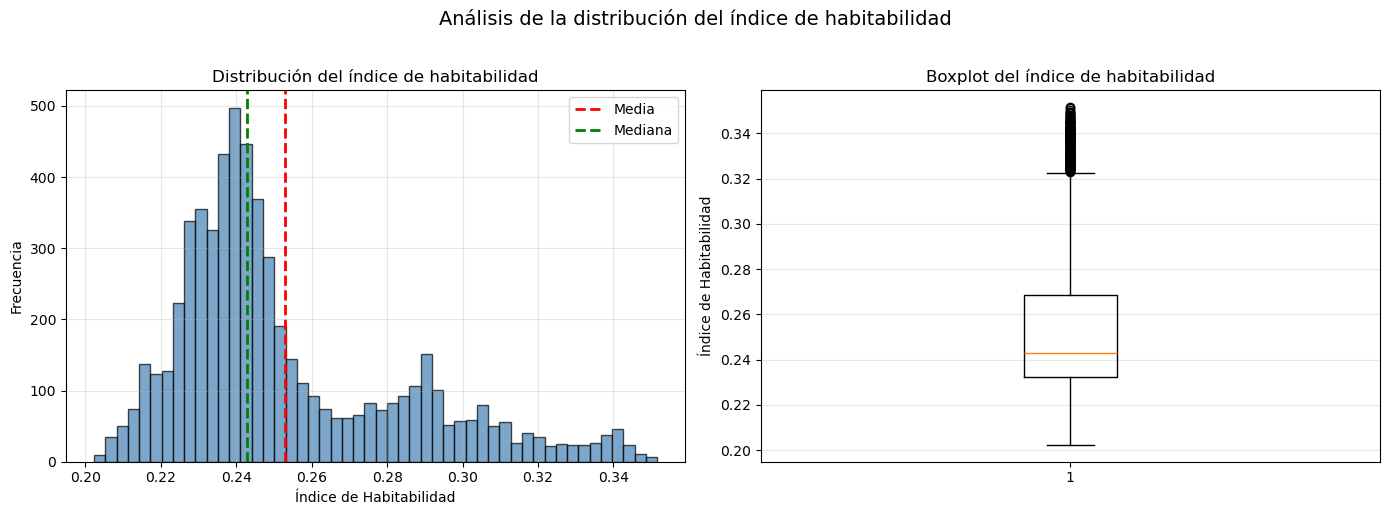

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_exoplanetas_habitabilidad['indice_habitabilidad'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Índice de Habitabilidad')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución del índice de habitabilidad')
axes[0].axvline(df_exoplanetas_habitabilidad['indice_habitabilidad'].mean(), color='red', linestyle='--', linewidth=2, label='Media')
axes[0].axvline(df_exoplanetas_habitabilidad['indice_habitabilidad'].median(), color='green', linestyle='--', linewidth=2, label='Mediana')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].boxplot(df_exoplanetas_habitabilidad['indice_habitabilidad'], vert=True)
axes[1].set_ylabel('Índice de Habitabilidad')
axes[1].set_title('Boxplot del índice de habitabilidad')
axes[1].grid(alpha=0.3, axis='y')

plt.suptitle('Análisis de la distribución del índice de habitabilidad', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### **Relación entre distancia euclídea e índice de habitabilidad**

Para visualizar la transformación aplicada, representamos la relación funcional entre la distancia euclídea al vector Tierra y el índice de habitabilidad resultante.

Esta gráfica muestra cómo la función $H_i = \frac{1}{1 + D_i}$ convierte las distancias en un índice acotado entre 0 y 1:

- **Distancias pequeñas** se mapean a **índices cercanos a 1** (alta similitud).
- **Distancias grandes** se mapean a **índices cercanos a 0** (baja similitud).
- La transformación es **no lineal**: pequeñas variaciones en distancia se reflejan más en el índice cuando estamos cerca del origen.

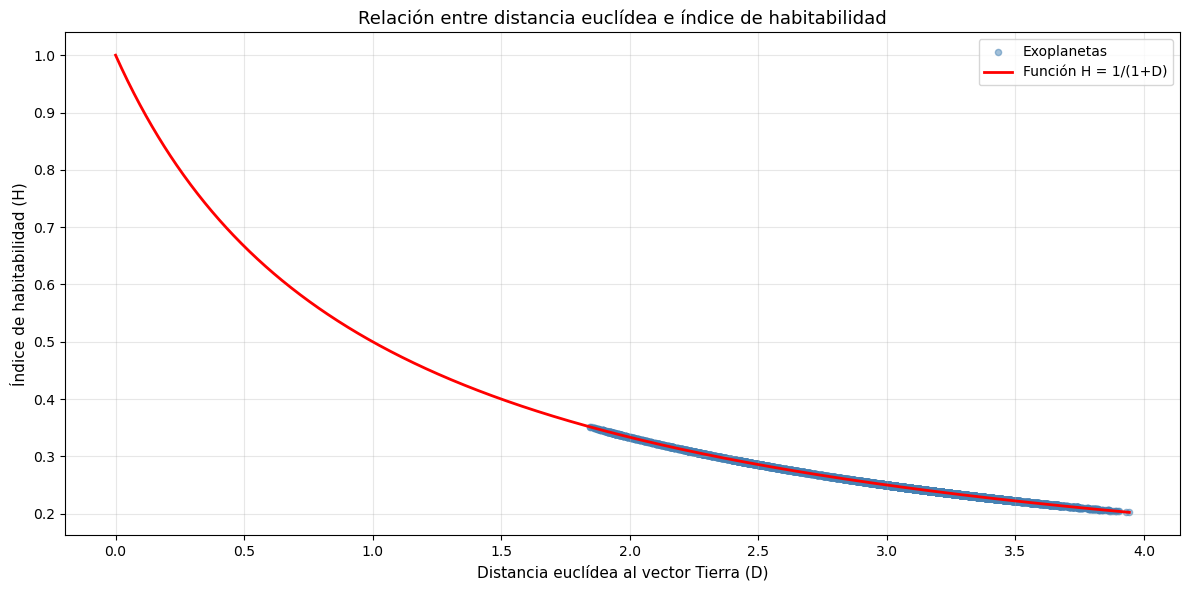

In [57]:
plt.figure(figsize=(12, 6))

plt.scatter(df_exoplanetas_habitabilidad['distancia_tierra'], 
            df_exoplanetas_habitabilidad['indice_habitabilidad'], 
            alpha=0.5, 
            s=20, 
            color='steelblue',
            label='Exoplanetas')

d_teorica = np.linspace(0, df_exoplanetas_habitabilidad['distancia_tierra'].max(), 1000)
h_teorica = 1 / (1 + d_teorica)
plt.plot(d_teorica, h_teorica, 'r-', linewidth=2, label='Función H = 1/(1+D)')

plt.xlabel('Distancia euclídea al vector Tierra (D)', fontsize=11)
plt.ylabel('Índice de habitabilidad (H)', fontsize=11)
plt.title('Relación entre distancia euclídea e índice de habitabilidad', fontsize=13)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### **Interpretación del índice de habitabilidad**

El índice de habitabilidad calculado mediante la transformación $H_i = \frac{1}{1 + D_i}$ presenta las siguientes características fundamentales:

- **Acotado**: el índice está siempre en el intervalo $(0, 1)$, facilitando la interpretación y comparación directa entre planetas.
- **Monotonía decreciente**: a mayor distancia euclídea, menor índice de habitabilidad. La relación es estrictamente decreciente.
- **Asíntota**: cuando $D_i \to \infty$, entonces $H_i \to 0$ (planetas infinitamente diferentes tienen habitabilidad nula).
- **Máximo teórico**: cuando $D_i = 0$, entonces $H_i = 1$ (planeta idéntico a la Tierra).

...

## **14. Generación del ranking**

Una vez calculado el índice de habitabilidad para cada exoplaneta, se procede a ordenar el conjunto completo de planetas en función de dicho valor, generando un ranking descendente desde los candidatos más similares a la Tierra hasta los menos compatibles según el criterio definido.

Este ranking transforma el índice en una herramienta operativa, permitiendo:

* identificar de forma inmediata los exoplanetas con mayor potencial de habitabilidad relativa
* comparar cuantitativamente todos los objetos del dataset bajo un mismo marco de referencia
* priorizar candidatos para análisis posteriores o estudios más detallados.

De este modo, el ranking proporciona una visión clara y estructurada del posicionamiento de cada planeta respecto al vector Tierra.

In [58]:

df_exoplanetas_ranking = df_exoplanetas_habitabilidad.sort_values('indice_habitabilidad', ascending=False).reset_index(drop=True)
df_exoplanetas_ranking.insert(0, 'ranking', range(1, len(df_exoplanetas_ranking) + 1))

columnas_ranking = ['ranking', 'pl_name', 'hostname', 'distancia_tierra', 'indice_habitabilidad']
df_exoplanetas_ranking[columnas_ranking].head(30)

,ranking,pl_name,hostname,distancia_tierra,indice_habitabilidad
0,1,KMT-2021-BLG-0912L b,KMT-2021-BLG-0912L,1.844252,0.351586
1,2,Kepler-1638 b,Kepler-1638,1.845849,0.351389
2,3,Kepler-1040 b,Kepler-1040,1.852877,0.350523
3,4,Kepler-1606 b,Kepler-1606,1.860648,0.349571
4,5,OGLE-2019-BLG-1053L b,OGLE-2019-BLG-1053L,1.861756,0.349436
5,6,KMT-2019-BLG-1806L b,KMT-2019-BLG-1806L,1.864254,0.349131
6,7,OGLE-2016-BLG-0007L b,OGLE-2016-BLG-0007L,1.865285,0.349005
7,8,Kepler-452 b,Kepler-452,1.870869,0.348327
8,9,Kepler-1090 b,Kepler-1090,1.873577,0.347998
9,10,KMT-2018-BLG-0029L b,KMT-2018-BLG-0029L,1.876084,0.347695


In [59]:
df_exoplanetas_ranking[df_exoplanetas_ranking['pl_name'] == 'LHS 1140 b'][columnas_ranking]

,ranking,pl_name,hostname,distancia_tierra,indice_habitabilidad
3602,3603,LHS 1140 b,LHS 1140,3.177589,0.239373


## **15. Interpretación del Top**
A partir del ranking obtenido, se analizan los exoplanetas mejor posicionados con el objetivo de interpretar sus características físicas y comprender qué variables están contribuyendo de manera más significativa a su alta puntuación de habitabilidad.

Este paso permite conectar el resultado numérico del índice con propiedades planetarias concretas, tales como tamaño, masa, condiciones orbitales o características de la estrella anfitriona, aportando una lectura física y cualitativa de los candidatos más prometedores.

La interpretación del Top no persigue establecer conclusiones definitivas sobre habitabilidad real, sino ofrecer una contextualización científica del ranking: identificar patrones comunes entre los primeros puestos, evaluar similitudes con la Tierra y detectar posibles sesgos derivados del propio diseño del índice o del conjunto de variables seleccionadas.

### **Comparación detallada: Planeta #1 vs. Tierra**

Para entender concretamente por qué el índice no es más alto, comparamos las características físicas del planeta mejor clasificado con las de la Tierra, variable por variable.

In [60]:
planeta_top1 = df_exoplanetas_ranking.iloc[0]

# Comparación detallada del planeta #1 con la Tierra
idx_top1 = df_exoplanetas_ranking.index[0]

print(f"COMPARACIÓN DETALLADA: {planeta_top1['pl_name']} vs. TIERRA")
print(f"\n{'Variable':20s} {'Planeta #1':>15s} {'Tierra':>15s} {'Desv. Escalada':>18s} {'Diferencia %':>15s}")
print("-"*100)

for var in num_cols:
    # Valores originales
    val_planeta = df_final.loc[idx_top1, var]
    val_tierra = vector_tierra[var]
    
    # Desviación escalada (con signo)
    desv_escalada = df_scaled.loc[idx_top1, var]
    
    # Diferencia porcentual respecto a Tierra (evitando división por 0)
    if val_tierra != 0:
        diff_pct = ((val_planeta - val_tierra) / abs(val_tierra)) * 100
    else:
        diff_pct = 0 if val_planeta == 0 else float('inf')
    
    print(f"{var:20s} {val_planeta:15.2f} {val_tierra:15.2f} {desv_escalada:15.2f} {diff_pct:12.1f}%")

COMPARACIÓN DETALLADA: KMT-2021-BLG-0912L b vs. TIERRA

Variable                  Planeta #1          Tierra     Desv. Escalada    Diferencia %
----------------------------------------------------------------------------------------------------
pl_orbper                       8.75          365.25           -2.67        -97.6%
pl_orbsmax                      0.08            1.00           -1.47        -91.8%
pl_orbeccen                     0.00            0.02           -0.10       -100.0%
pl_rade                         3.56            1.00            0.15        255.8%
pl_bmasse                      12.40            1.00            0.03       1140.0%
pl_dens                         1.51            5.51           -0.43        -72.6%
pl_eqt                        840.29          255.00            0.30        229.5%
pl_insol                      117.83            1.00            0.18      11682.6%
st_teff                      5525.00         5778.00           -0.07         -4.4%
st_lum  

### **Visualización de desviaciones: Top 1 vs. Tierra**

Representamos gráficamente las desviaciones escaladas del planeta #1 respecto a la Tierra para visualizar en qué variables específicas se concentran las diferencias.

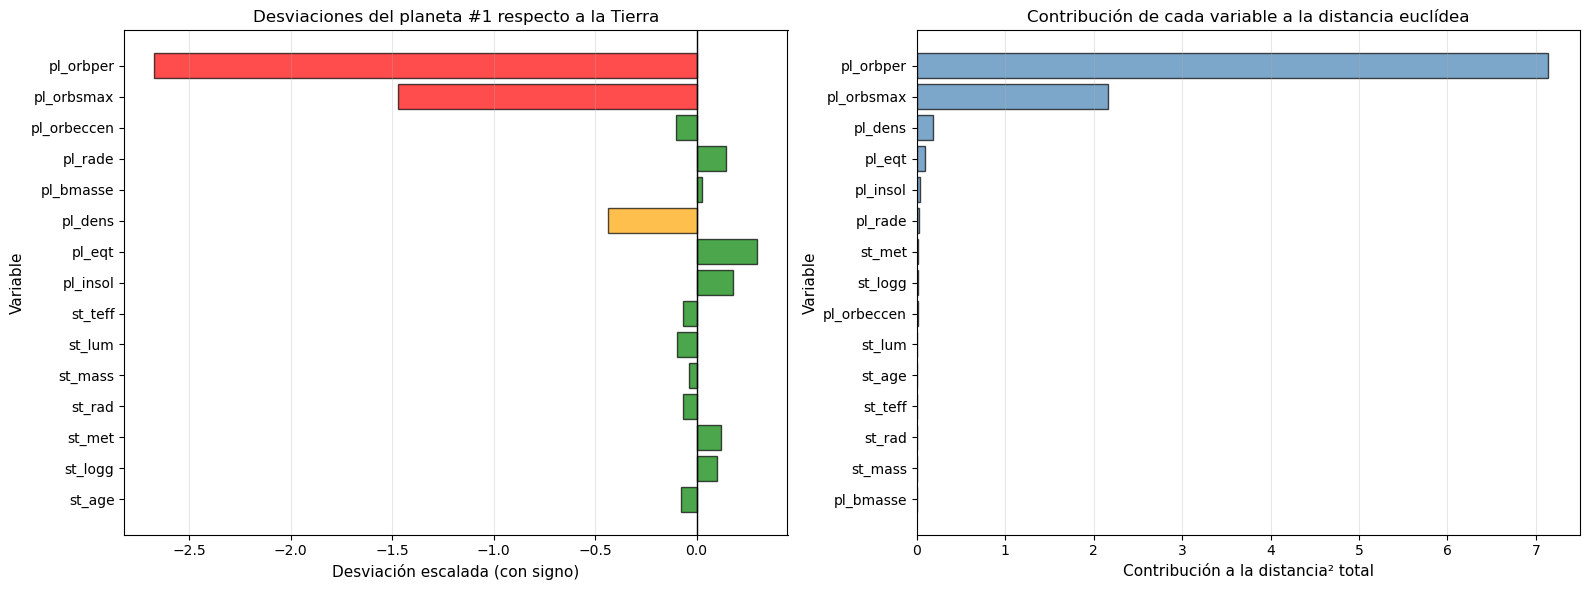

In [61]:
desviaciones_top1 = df_scaled.loc[idx_top1, num_cols]
desviaciones_abs_top1 = df_deviations.loc[idx_top1, num_cols]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['green' if abs(x) < 0.3 else 'orange' if abs(x) < 0.6 else 'red' for x in desviaciones_top1]
axes[0].barh(num_cols, desviaciones_top1, color=colors, alpha=0.7, edgecolor='black')
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=1)
axes[0].set_xlabel('Desviación escalada (con signo)', fontsize=11)
axes[0].set_ylabel('Variable', fontsize=11)
axes[0].set_title(f'Desviaciones del planeta #{1} respecto a la Tierra', fontsize=12)
axes[0].grid(alpha=0.3, axis='x')
axes[0].invert_yaxis()

contribuciones = desviaciones_abs_top1 ** 2
contribuciones_sorted = contribuciones.sort_values(ascending=True)
axes[1].barh(contribuciones_sorted.index, contribuciones_sorted.values, 
             color='steelblue', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Contribución a la distancia² total', fontsize=11)
axes[1].set_ylabel('Variable', fontsize=11)
axes[1].set_title('Contribución de cada variable a la distancia euclídea', fontsize=12)
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

### **Visualización del ranking: decaimiento del índice de habitabilidad**

Para entender mejor cómo se distribuyen los exoplanetas a lo largo del ranking, representamos gráficamente el índice de habitabilidad en función de la posición en el ranking.

Esta visualización permite identificar:
- La **tasa de decaimiento** del índice a lo largo del ranking.
- Si existen **saltos bruscos** o **grupos diferenciados** de planetas.
- La **separación** entre los candidatos más prometedores y el resto del catálogo.

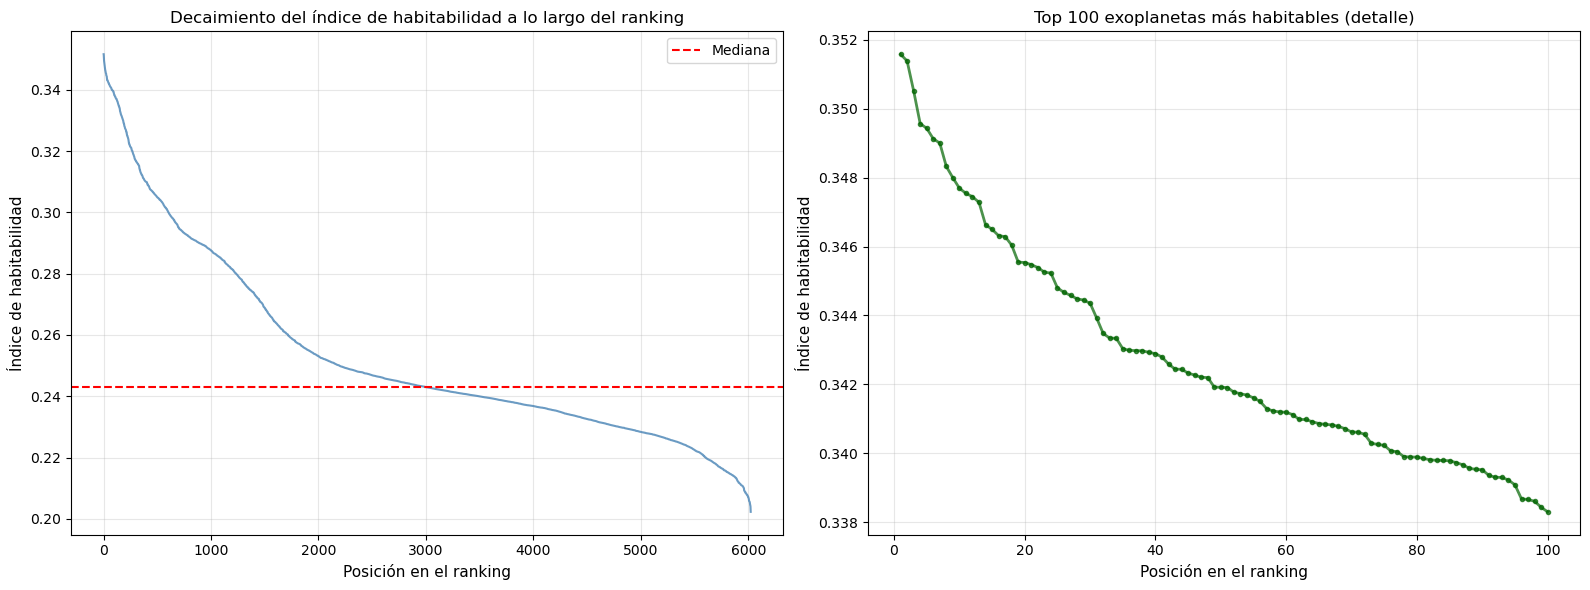

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(df_exoplanetas_ranking['ranking'], df_exoplanetas_ranking['indice_habitabilidad'], 
             linewidth=1.5, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Posición en el ranking', fontsize=11)
axes[0].set_ylabel('Índice de habitabilidad', fontsize=11)
axes[0].set_title('Decaimiento del índice de habitabilidad a lo largo del ranking', fontsize=12)
axes[0].grid(alpha=0.3)
axes[0].axhline(y=df_exoplanetas_ranking['indice_habitabilidad'].median(), 
                color='red', linestyle='--', linewidth=1.5, label='Mediana')
axes[0].legend()

top_100 = df_exoplanetas_ranking.head(100)
axes[1].plot(top_100['ranking'], top_100['indice_habitabilidad'], 
             linewidth=2, color='darkgreen', marker='o', markersize=3, alpha=0.7)
axes[1].set_xlabel('Posición en el ranking', fontsize=11)
axes[1].set_ylabel('Índice de habitabilidad', fontsize=11)
axes[1].set_title('Top 100 exoplanetas más habitables (detalle)', fontsize=12)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### **Análisis del índice máximo de habitabilidad obtenido**

**1. Relación matemática índice-distancia**

Con la fórmula $H_i = \frac{1}{1 + D_i}$, la relación entre el índice de habitabilidad y la distancia euclídea es:

- **Índice 1.0** → requiere distancia = 0 (planeta **idéntico** a la Tierra en todas las variables)
- **Índice 0.75** → requiere distancia ≈ 0.33
- **Índice 0.50** → requiere distancia = 1.0
- **Índice 0.35** → corresponde a distancia ≈ 1.84
- **Índice 0.25** → corresponde a distancia = 3.0

Un índice de 0.35 refleja una distancia euclídea moderada en el espacio multidimensional, no un error del modelo.

**2. Espacio multidimensional (15 variables)**

La distancia euclídea se calcula sobre **15 dimensiones físicas diferentes** (parámetros orbitales, planetarios y estelares):

$$D_i = \sqrt{\sum_{j=1}^{15} (x_{ij}^{scaled})^2}$$

- Una distancia de 1.84 equivale a una **desviación promedio de ~0.47 por variable** ($\frac{1.84}{\sqrt{15}} \approx 0.47$)
- Incluso pequeñas diferencias en cada dimensión se **acumulan geométricamente**
- Es extremadamente difícil estar cerca de 0 en todas las variables simultáneamente

**3. Escala basada en percentiles robustos (P99-P01)**

Las variables están escaladas usando el rango típico del dataset:

$$x_i^{scaled} = \frac{x_i - x_{\oplus}}{P_{99}(x) - P_{01}(x)}$$

- Una desviación de 0.5 significa que el planeta está **a mitad del rango típico** del dataset respecto a la Tierra
- Las desviaciones se miden como **fracción del rango observado**, no en valores absolutos
- Esta escala hace que todas las variables contribuyan de forma equilibrada, pero también que sea difícil lograr valores muy bajos en todas

**4. Sesgos observacionales del catálogo**

Los métodos actuales de detección de exoplanetas favorecen ciertos tipos de planetas:

- **Método de tránsitos**: detecta mejor planetas grandes y cercanos a sus estrellas
- **Velocidad radial**: favorece planetas masivos en órbitas cortas
- **Planetas tipo Tierra** (pequeños, órbitas amplias, estrellas tipo solar) son **mucho más difíciles de detectar**

El catálogo está **dominado por**:
- "Hot Jupiters" (gigantes gaseosos muy cercanos a sus estrellas)
- "Super-Tierras" en órbitas cortas
- Planetas alrededor de estrellas enanas rojas (más fáciles de detectar)

**5. Unicidad de la Tierra en el universo observable**

- La Tierra es el **único caso confirmado** de planeta habitable en el universo conocido
- No esperamos encontrar "clones exactos" de la Tierra
- La probabilidad de que un planeta coincida con la Tierra en **todas las variables físicas simultáneamente** es extremadamente baja
- Un índice de 0.35 representa el **mejor candidato disponible dentro del catálogo actual**, no perfección

**6. Contexto estadístico del dataset**

El catálogo de exoplanetas confirmados:
- Contiene principalmente planetas muy diferentes de la Tierra
- Refleja las limitaciones tecnológicas actuales de detección
- No es una muestra representativa del universo, sino una muestra sesgada por detectabilidad

#### **Conclusión**

Un índice máximo de habitabilidad de **~0.35** es el resultado esperado dada:

- La **física del problema** (distancias en espacios multidimensionales)
- La **diversidad real** de exoplanetas observados
- Las **limitaciones observacionales** actuales
- La **unicidad** de las condiciones terrestres

Este valor representa el exoplaneta **más similar a la Tierra dentro del catálogo disponible**, reconociendo que existen diferencias significativas en múltiples variables físicas. El índice cumple su función: **ordenar y priorizar** los candidatos según similitud física, sin pretender encontrar réplicas exactas de la Tierra.

## **16. Coherencia y validación empírica del índice**
Una vez construido el índice de habitabilidad y generado el ranking, es necesario comprobar si el comportamiento global del indicador resulta coherente con lo que cabría esperar desde un punto de vista físico. Esta etapa no pretende validar el índice en sentido experimental, sino evaluar si su distribución y relaciones internas son razonables y consistentes.

En primer lugar, se analiza la distribución del índice mediante un histograma. Dado que la habitabilidad es un fenómeno extremadamente restrictivo, lo esperable es observar una concentración mayoritaria de planetas en valores bajos del índice y un número muy reducido de objetos con puntuaciones próximas a 1. Si la distribución mostrara una abundancia elevada de planetas altamente similares a la Tierra, ello indicaría un problema en la definición o calibración del indicador. Por tanto, una asimetría hacia valores bajos constituye un resultado coherente con el conocimiento actual sobre la rareza de condiciones habitables.

De forma complementaria, puede emplearse un boxplot para caracterizar la mediana, la dispersión y la presencia de valores extremos. Esta representación permite identificar si los planetas mejor clasificados constituyen verdaderos outliers respecto al conjunto global, reforzando la idea de que la habitabilidad corresponde a una región muy específica del espacio de parámetros.

En segundo lugar, se comparan las características físicas medias del grupo de planetas mejor posicionados frente al resto del dataset. Esta comparación permite verificar si el índice está capturando diferencias reales en variables relevantes como radio planetario, masa, temperatura estelar o distancia orbital. Si el grupo Top presenta, en promedio, valores más cercanos a los terrestres, ello aporta evidencia indirecta de que el índice está funcionando como se esperaba.

Asimismo, pueden explorarse relaciones bivariantes simples entre el índice y algunas variables clave. Estas representaciones permiten comprobar si el indicador penaliza adecuadamente las desviaciones extremas y si existen regiones de parámetros donde la habitabilidad relativa se concentra.

En conjunto, este análisis gráfico permite:

* comprobar la plausibilidad global del índice
* detectar posibles sesgos estructurales
* identificar anomalías
* reforzar la interpretación física del ranking obtenido

De forma conceptual, este comportamiento distributivo conecta con lo que se conoce en cosmología como **Ajuste fino del universo**. Según el cual, la aparición de estructuras complejas requiere que múltiples parámetros se encuentren dentro de rangos estrechos. En el contexto de este trabajo, la baja densidad de planetas con índice elevado refleja precisamente que las condiciones próximas a la habitabilidad emergen solo cuando diversas variables orbitales, planetarias y estelares se alinean dentro de márgenes reducidos.

=== MÉTRICAS DESCRIPTIVAS ===
Media: 0.2530
Mediana: 0.2429
Skewness: 1.1340
Curtosis: 0.6094


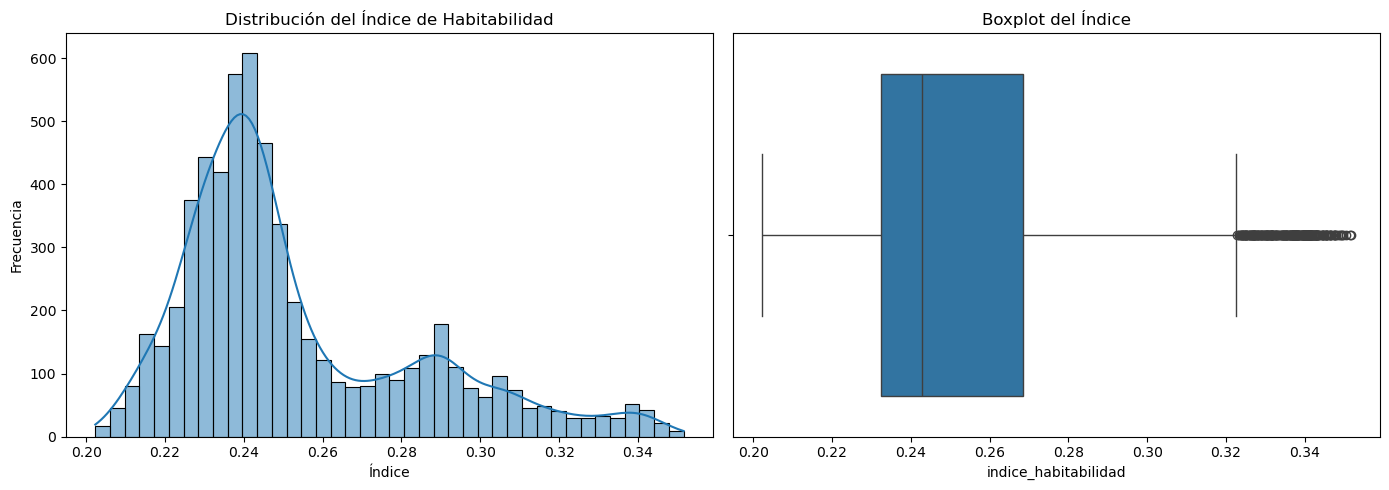


=== COMPARACIÓN TOP 5% vs RESTO ===


,Media Top,Media Resto
pl_rade,0.264883,0.274029
pl_bmasse,0.098577,0.256354
pl_orbsmax,0.626603,1.298325
st_teff,0.089606,0.179225
pl_eqt,0.041252,0.304295


In [116]:
#impirmimos algunas métricas descriptivas

indice = df_exoplanetas_ranking["indice_habitabilidad"]

media = np.mean(indice)
mediana = np.median(indice)
sk = skew(indice)
curt = kurtosis(indice)

print("=== MÉTRICAS DESCRIPTIVAS ===")
print(f"Media: {media:.4f}")
print(f"Mediana: {mediana:.4f}")
print(f"Skewness: {sk:.4f}")
print(f"Curtosis: {curt:.4f}")

# # Análisis distributivo del índice - Histograma y Boxplot

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Histograma
sns.histplot(indice, bins=40, kde=True, ax=axes[0])
axes[0].set_title("Distribución del Índice de Habitabilidad")
axes[0].set_xlabel("Índice")
axes[0].set_ylabel("Frecuencia")

# Boxplot
sns.boxplot(x=indice, ax=axes[1])
axes[1].set_title("Boxplot del Índice")

plt.tight_layout()
plt.show()

# comparando el TOP vs el resto
#definimos un límite

limite = indice.quantile(0.95)

top = df_exoplanetas_ranking[
    df_exoplanetas_ranking["indice_habitabilidad"] >= limite
]

resto = df_exoplanetas_ranking[
    df_exoplanetas_ranking["indice_habitabilidad"] < limite
]

#seleccionamos las variables físicas
vars_fisicas = ["pl_rade", "pl_bmasse", "pl_orbsmax", "st_teff", "pl_eqt"]


#hacemos la comparación
comparacion = pd.DataFrame({
    "Media Top": top[vars_fisicas].mean(),
    "Media Resto": resto[vars_fisicas].mean(),
})

print("\n=== COMPARACIÓN TOP 5% vs RESTO ===")
display(comparacion)

La distribución presenta una marcada asimetría hacia valores bajos, coherente con el carácter restrictivo del fenómeno de habitabilidad.

Los planetas mejor clasificados constituyen verdaderos outliers respecto al conjunto global, reforzando la idea de que la habitabilidad corresponde a una región muy específica del espacio de parámetros.

Esta comparación permite verificar que el índice está capturando diferencias reales en variables relevantes como radio planetario, masa, temperatura estelar o distancia orbital. El grupo Top presenta, en promedio, valores más cercanos a los terrestres, ello aporta evidencia indirecta de que el índice está funcionando como se esperaba.

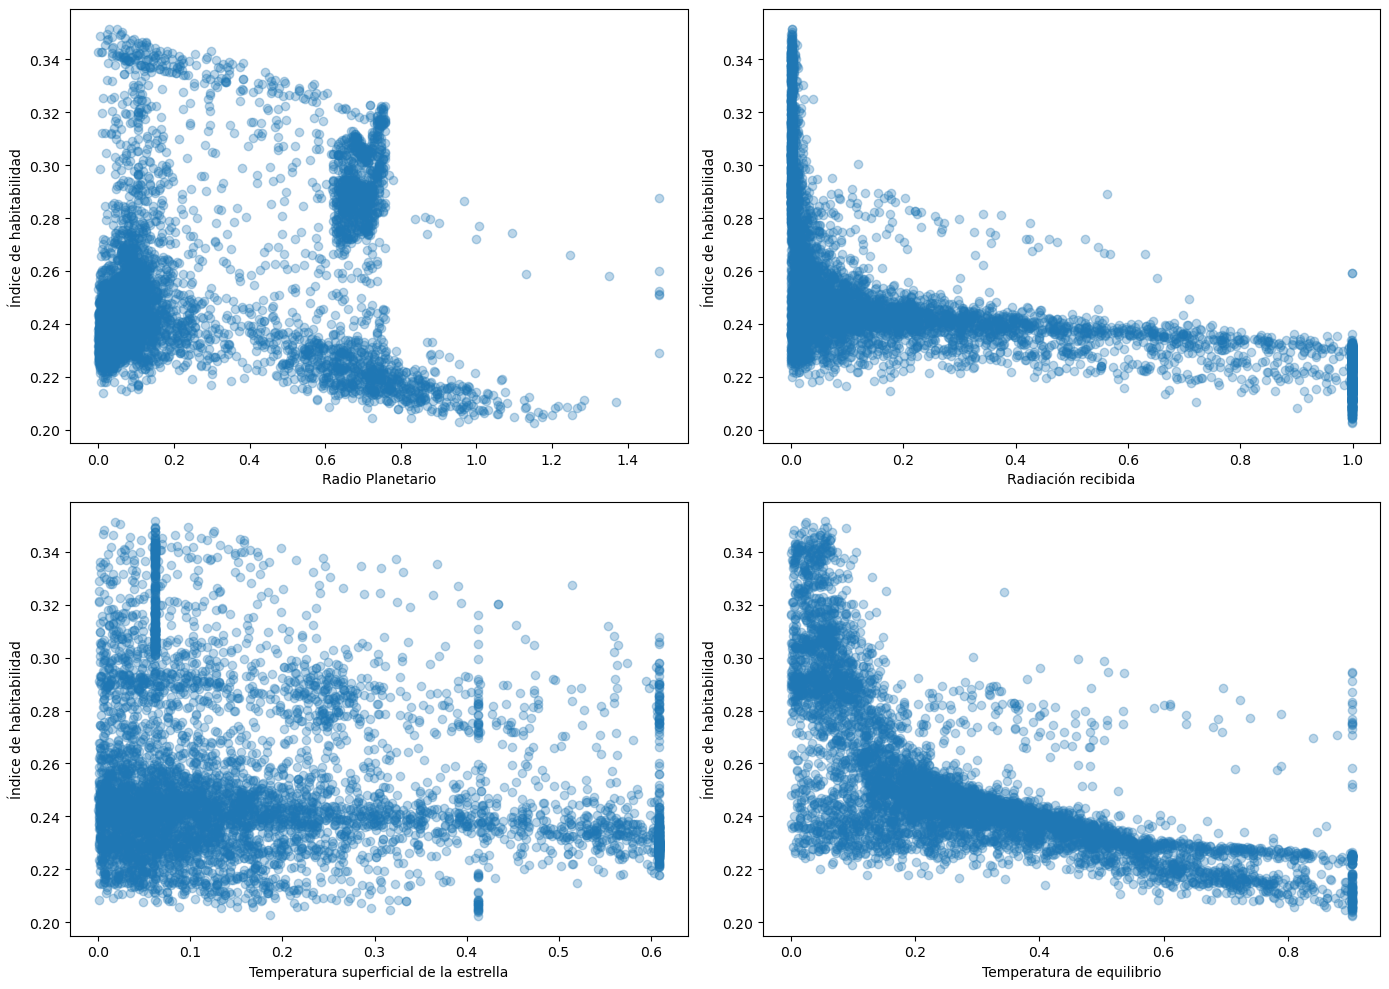

In [120]:
# Relaciones bivariantes

fig, axes = plt.subplots(2, 2, figsize=(14,10))

#índice vs rádio
axes[0,0].scatter(df_exoplanetas_ranking["pl_rade"],
                  df_exoplanetas_ranking["indice_habitabilidad"], alpha=0.3)
axes[0,0].set_xlabel("Radio Planetario")
axes[0,0].set_ylabel("Índice de habitabilidad")

#índice vs Radiación recibida
axes[0,1].scatter(df_exoplanetas_ranking["pl_insol"],
                  df_exoplanetas_ranking["indice_habitabilidad"], alpha=0.3)
axes[0,1].set_xlabel("Radiación recibida")
axes[0,1].set_ylabel("Índice de habitabilidad")

#índice vs Temperatura superficial de la estrella
axes[1,0].scatter(df_exoplanetas_ranking["st_teff"],
                  df_exoplanetas_ranking["indice_habitabilidad"], alpha=0.3)
axes[1,0].set_xlabel("Temperatura superficial de la estrella")
axes[1,0].set_ylabel("Índice de habitabilidad")

#índice vs temperatura de equilibrio 
axes[1,1].scatter(df_exoplanetas_ranking["pl_eqt"],
                  df_exoplanetas_ranking["indice_habitabilidad"], alpha=0.3)
axes[1,1].set_xlabel("Temperatura de equilibrio")
axes[1,1].set_ylabel("Índice de habitabilidad")

plt.tight_layout()
plt.show()

El análisis bivariante confirma que el índice penaliza desviaciones extremas de los valores terrestres y muestra que existen regiones de parámetros donde la habitabilidad relativa se concentra.


## **17. Análisis de sensibilidad del índice**

En este apartado se evalúa hasta qué punto el índice de habitabilidad depende del esquema de reescalado utilizado para limitar la influencia de valores extremos.

En la construcción original del índice, las variables fueron reescaladas utilizando un recorte basado en percentiles (1–99) para limitar la influencia de valores extremos.

En este análisis se repite exactamente el mismo procedimiento, modificando únicamente el intervalo de recorte, por ejemplo:

* configuración original: percentiles 1–99
* configuración alternativa: **percentiles 5–95**, al representar una variación razonable del tratamiento de valores extremos sin modificar sustancialmente la estructura del conjunto de datos.

**Pasos operativos**

1. Cambiar los percentiles en la fórmula de recorte (5–95).

2. Recalcular las variables reescaladas.

3. Volver a calcular:

* desviaciones respecto al vector Tierra
* agregación de desviaciones
* índice final
* ranking completo.

4. Comparar ambos rankings.

**Qué comparar exactamente**

* Coincidencia del Top 5 o Top 10.
* Cambios de posición en los primeros puestos.
* Si algún planeta desaparece completamente del Top.

**Interpretación**

* Si el Top se mantiene mayoritariamente: el índice es robusto frente a cambios razonables en el tratamiento de extremos.
* Si el ranking cambia drásticamente: el modelo es muy sensible al recorte elegido.

In [121]:
def construir_ranking_habitabilidad(df_final, num_cols, vector_tierra, p_low=0.01, p_high=0.99):
    # Calculamos los percentiles para cada variable numérica
    pL = df_final[num_cols].quantile(p_low)
    pH = df_final[num_cols].quantile(p_high)

    rango_tipico = pH - pL

    percentiles_df = pd.DataFrame({
        'PL': pL,
        'PH': pH,
        'Rango (PH-PL)': rango_tipico
    })

    # Aplicamos el escalado relativo respecto al vector Tierra
    df_scaled = df_final.copy()

    for col in num_cols:
        x_earth = vector_tierra[col]
        rango = rango_tipico[col]
        df_scaled[col] = (df_final[col] - x_earth) / rango

    df_deviations = df_scaled.copy()
    df_deviations[num_cols] = df_scaled[num_cols].abs()

    df_distance = df_deviations.copy()
    df_distance['distancia_tierra'] = np.sqrt((df_deviations[num_cols] ** 2).sum(axis=1))

    df_hab = df_distance.copy()
    df_hab['indice_habitabilidad'] = 1 / (1 + df_hab['distancia_tierra'])

    df_ranking = df_hab.sort_values('indice_habitabilidad', ascending=False).reset_index(drop=True)
    df_ranking.insert(0, 'ranking', range(1, len(df_ranking) + 1))

    return df_ranking, df_scaled, percentiles_df


In [122]:
ranking_01_99, scaled_01_99, percs_01_99 = construir_ranking_habitabilidad(
    df_final=df_final,
    num_cols=num_cols,
    vector_tierra=vector_tierra,
    p_low=0.01,
    p_high=0.99
)

ranking_05_95, scaled_05_95, percs_05_95 = construir_ranking_habitabilidad(
    df_final=df_final,
    num_cols=num_cols,
    vector_tierra=vector_tierra,
    p_low=0.05,
    p_high=0.95
)


In [123]:
top5_a = set(ranking_01_99.head(5)["pl_name"])
top5_b = set(ranking_05_95.head(5)["pl_name"])

top10_a = set(ranking_01_99.head(10)["pl_name"])
top10_b = set(ranking_05_95.head(10)["pl_name"])

print("Coincidencia Top 5:", len(top5_a & top5_b), "de 5")
print("Coincidencia Top 10:", len(top10_a & top10_b), "de 10")

print("\nTop 5 comunes:", sorted(list(top5_a & top5_b)))
print("En Top 5 (1–99) pero no en (5–95):", sorted(list(top5_a - top5_b)))
print("En Top 5 (5–95) pero no en (1–99):", sorted(list(top5_b - top5_a)))


Coincidencia Top 5: 4 de 5
Coincidencia Top 10: 10 de 10

Top 5 comunes: ['KMT-2021-BLG-0912L b', 'Kepler-1040 b', 'Kepler-1606 b', 'Kepler-1638 b']
En Top 5 (1–99) pero no en (5–95): ['OGLE-2019-BLG-1053L b']
En Top 5 (5–95) pero no en (1–99): ['KMT-2019-BLG-1806L b']


In [124]:
rA = ranking_01_99[["pl_name", "ranking", "indice_habitabilidad"]].rename(
    columns={"ranking":"rank_01_99", "indice_habitabilidad":"idx_01_99"}
)
rB = ranking_05_95[["pl_name", "ranking", "indice_habitabilidad"]].rename(
    columns={"ranking":"rank_05_95", "indice_habitabilidad":"idx_05_95"}
)

cmp = rA.merge(rB, on="pl_name", how="inner")
cmp["delta_rank"] = cmp["rank_05_95"] - cmp["rank_01_99"]

cmp_top = cmp.sort_values("rank_01_99").head(30)
cmp_top[["pl_name", "rank_01_99", "rank_05_95", "delta_rank", "idx_01_99", "idx_05_95"]]


,pl_name,rank_01_99,rank_05_95,delta_rank,idx_01_99,idx_05_95
0,KMT-2021-BLG-0912L b,1,2,1,0.351586,0.349257
1,Kepler-1638 b,2,1,-1,0.351389,0.349337
2,Kepler-1040 b,3,3,0,0.350523,0.348440
3,Kepler-1606 b,4,4,0,0.349571,0.347043
4,OGLE-2019-BLG-1053L b,5,6,1,0.349436,0.346517
5,KMT-2019-BLG-1806L b,6,5,-1,0.349131,0.346575
6,OGLE-2016-BLG-0007L b,7,7,0,0.349005,0.345948
7,Kepler-452 b,8,10,2,0.348327,0.344734
8,Kepler-1090 b,9,9,0,0.347998,0.345143
9,KMT-2018-BLG-0029L b,10,8,-2,0.347695,0.345207


In [125]:
top10_only_a = top10_a - top10_b
top10_only_b = top10_b - top10_a

print("Desaparecen del Top 10 al pasar 1–99 -> 5–95:", sorted(list(top10_only_a)))
print("Aparecen nuevos en el Top 10 al pasar 1–99 -> 5–95:", sorted(list(top10_only_b)))


Desaparecen del Top 10 al pasar 1–99 -> 5–95: []
Aparecen nuevos en el Top 10 al pasar 1–99 -> 5–95: []


In [126]:
coinc_top10 = len(top10_a & top10_b)

if coinc_top10 >= 7:
    print("Interpretación: el ranking es mayoritariamente estable; el índice parece robusto ante cambios razonables del recorte.")
elif coinc_top10 >= 4:
    print("Interpretación: hay sensibilidad moderada; el tratamiento de extremos afecta el Top, pero no lo altera por completo.")
else:
    print("Interpretación: el ranking cambia drásticamente; el índice es muy sensible al recorte elegido.")


Interpretación: el ranking es mayoritariamente estable; el índice parece robusto ante cambios razonables del recorte.


In [127]:
from scipy.stats import spearmanr

corr_spearman = spearmanr(cmp["rank_01_99"], cmp["rank_05_95"]).correlation
print("Spearman (rankings):", round(corr_spearman, 4))


Spearman (rankings): 0.9971


In [128]:
df_exoplanetas_ranking = ranking_01_99  # o ranking_05_95
df_scaled = scaled_01_99               # o scaled_05_95


## **18. Conclusiones**

En este apartado se recogen las conclusiones generales del trabajo a partir del índice construido, el ranking obtenido y los análisis posteriores. Se sintetiza el enfoque seguido y se comentan de forma breve los patrones observados en los resultados, siempre en términos de similitud relativa con la Tierra y sin pretender establecer afirmaciones sobre habitabilidad real.

Asimismo, se resumen las principales limitaciones del modelo y del conjunto de datos utilizado.

## **19. Posibles mejoras y líneas de ampliación**

Este apartado recoge extensiones metodológicas aplicables directamente al mismo dataset y al índice ya construido.

Una primera línea de mejora consiste en analizar de forma sistemática la redundancia entre variables antes del cálculo del índice. Dado que varias magnitudes planetarias y estelares están físicamente relacionadas, un estudio previo de correlaciones o componentes principales permitiría identificar dimensiones dominantes y reducir colinealidad, evitando que información equivalente influya varias veces en el resultado final.

También puede profundizarse en el tratamiento de incertidumbres observacionales. El dataset contiene valores estimados con distintos niveles de fiabilidad; incorporar estas incertidumbres en forma de rangos o simulaciones simples permitiría evaluar la estabilidad del índice frente al error de medida, aportando una dimensión adicional al análisis de sensibilidad.

Asimismo, el esquema actual de agregación considera todas las variables de forma equivalente. Una mejora a estudiar sería el impacto de introducir ponderaciones basadas en relevancia física o en variabilidad estadística, comparando el ranking resultante con el modelo no ponderado.

Estas mejoras permanecen estrictamente dentro del conjunto de datos original y del marco del índice definido, y permiten transformar el trabajo actual en una plataforma experimental más rica para explorar la influencia de decisiones metodológicas sobre la priorización de exoplanetas.